In [1]:
import os
import glob
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Function to load TensorBoard logs
def load_tensorboard_logs(log_dir):
    event_files = glob.glob(os.path.join(log_dir, 'events.out.tfevents.*'))
    if not event_files:
        return None
    event_file = max(event_files, key=os.path.getctime)  # Get the latest event file
    ea = EventAccumulator(event_file)
    ea.Reload()
    print(f"Available scalar tags in {log_dir}: {ea.Tags()['scalars']}")
    return ea

# Function to extract scalar values
def extract_scalars(ea, tag):
    if tag in ea.Tags()['scalars']:
        return [(s.step, s.value) for s in ea.Scalars(tag)]
    return []

In [9]:
# Paths to the run directories
run_dirs = [
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41',
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41_1',
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41_2',
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41_3',
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41_4',
    r'c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41_5'
]

agents = ['Hider0', 'Hider1', 'Hider2', 'Seeker0', 'Seeker1', 'Seeker2']

# For each run, for each agent, load logs
data = {}
for run_dir in run_dirs:
    run_name = os.path.basename(run_dir)
    data[run_name] = {}
    for agent in agents:
        agent_dir = os.path.join(run_dir, agent)
        if os.path.exists(agent_dir):
            ea = load_tensorboard_logs(agent_dir)
            if ea:
                data[run_name][agent] = {
                    'entropy': extract_scalars(ea, 'Policy/Entropy'),
                    'reward': extract_scalars(ea, 'Environment/Cumulative Reward'),
                    'loss': extract_scalars(ea, 'Policy/Loss'),
                    'episode_length': extract_scalars(ea, 'Environment/Episode Length')
                }
            else:
                data[run_name][agent] = None

Available scalar tags in c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41\Hider0: ['Policy/Entropy', 'Environment/SeekersMeanX', 'Environment/SeekersMeanZ', 'Environment/HidersMeanX', 'Environment/HidersMeanZ', 'Environment/Episode Length', 'Environment/TimeHidden', 'Environment/HiderWinRatio', 'Self-play/ELO', 'Policy/Extrinsic Value Estimate', 'Policy/Curiosity Value Estimate', 'Environment/Cumulative Reward', 'Policy/Extrinsic Reward', 'Policy/Curiosity Reward']
Available scalar tags in c:\Users\BBBS-AI-01\d\rl\unity_proj\unity-hide-and-seek\results\run41\Hider1: ['Policy/Entropy', 'Environment/SeekersMeanX', 'Environment/SeekersMeanZ', 'Environment/HidersMeanX', 'Environment/HidersMeanZ', 'Environment/Episode Length', 'Environment/TimeHidden', 'Environment/HiderWinRatio', 'Self-play/ELO', 'Policy/Extrinsic Value Estimate', 'Policy/Curiosity Value Estimate', 'Environment/Cumulative Reward', 'Policy/Extrinsic Reward', 'Policy/Curiosity Reward']
Available scalar t

## Exploration and Exploitation Study

### 1. Observing the shift from exploration to exploitation

The entropy of the policy indicates the level of exploration. High entropy means the agent is exploring more (random actions), low entropy means exploiting (deterministic actions based on learned policy).

Plot entropy over training steps to see when it starts decreasing.

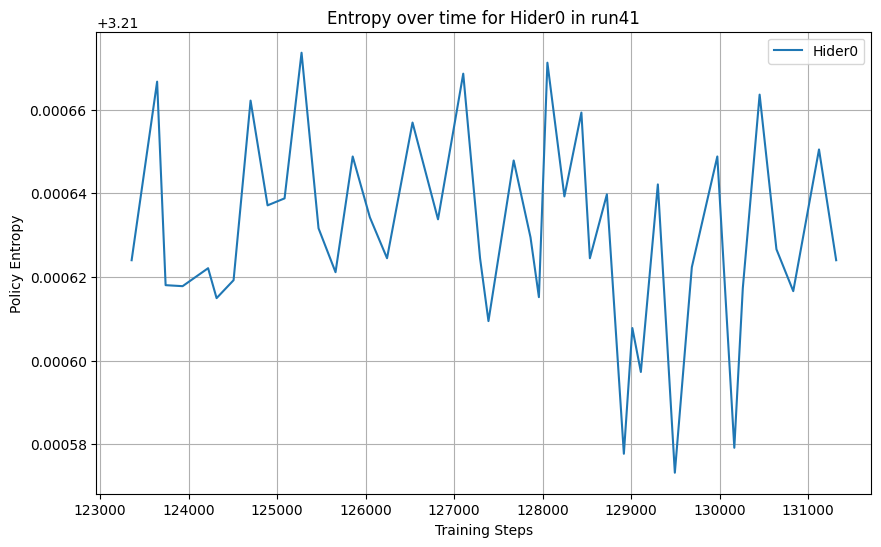

Hider0 in run41: Early entropy avg: 3.2106, Late entropy avg: 3.2106
  -> Still mostly exploring


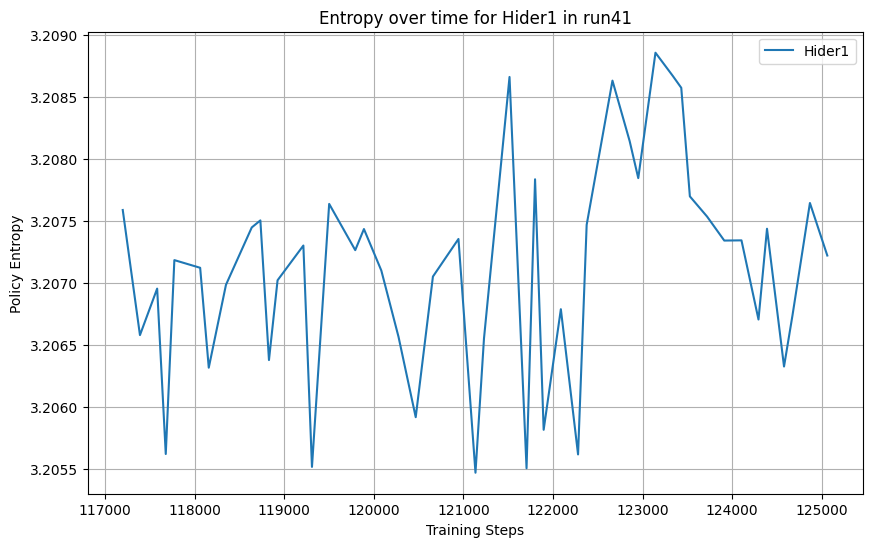

Hider1 in run41: Early entropy avg: 3.2069, Late entropy avg: 3.2072
  -> Still mostly exploring


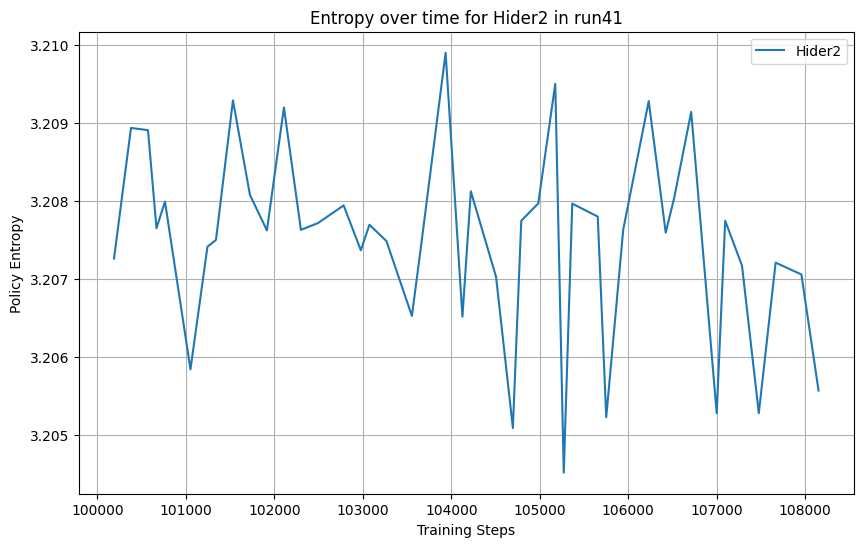

Hider2 in run41: Early entropy avg: 3.2079, Late entropy avg: 3.2070
  -> Still mostly exploring


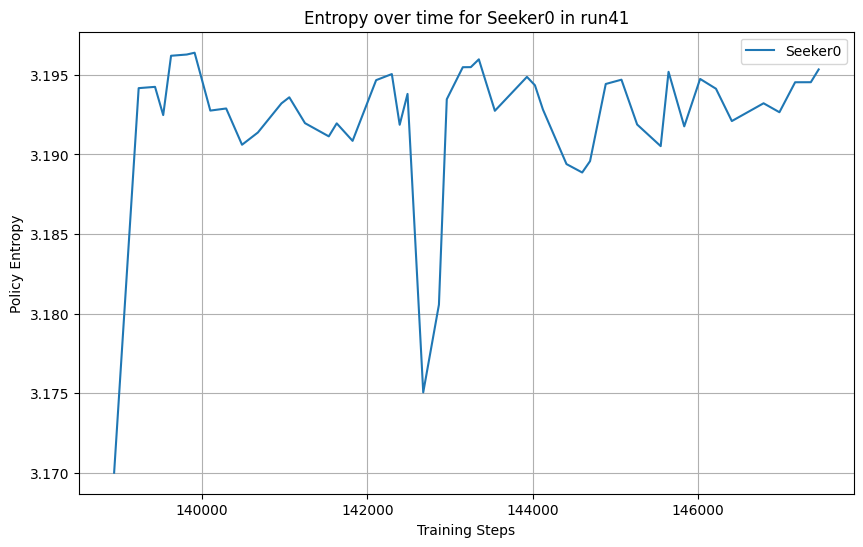

Seeker0 in run41: Early entropy avg: 3.1916, Late entropy avg: 3.1938
  -> Still mostly exploring


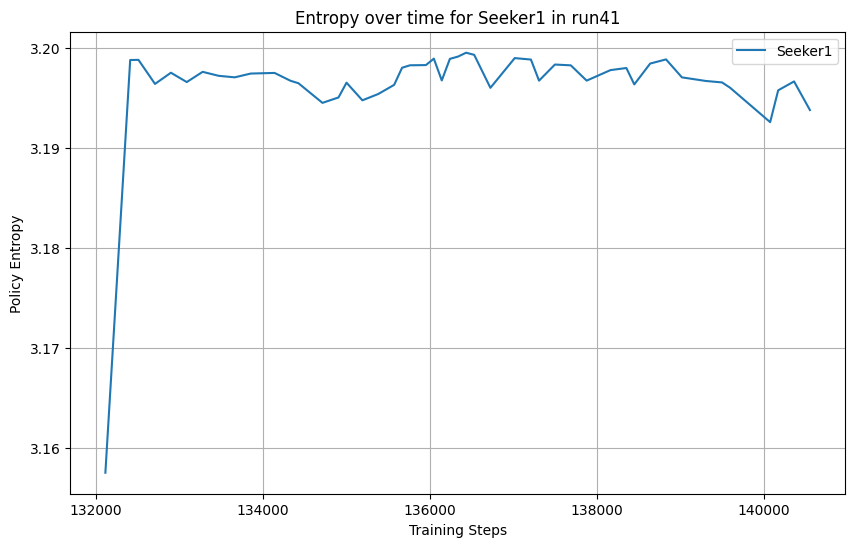

Seeker1 in run41: Early entropy avg: 3.1935, Late entropy avg: 3.1962
  -> Still mostly exploring


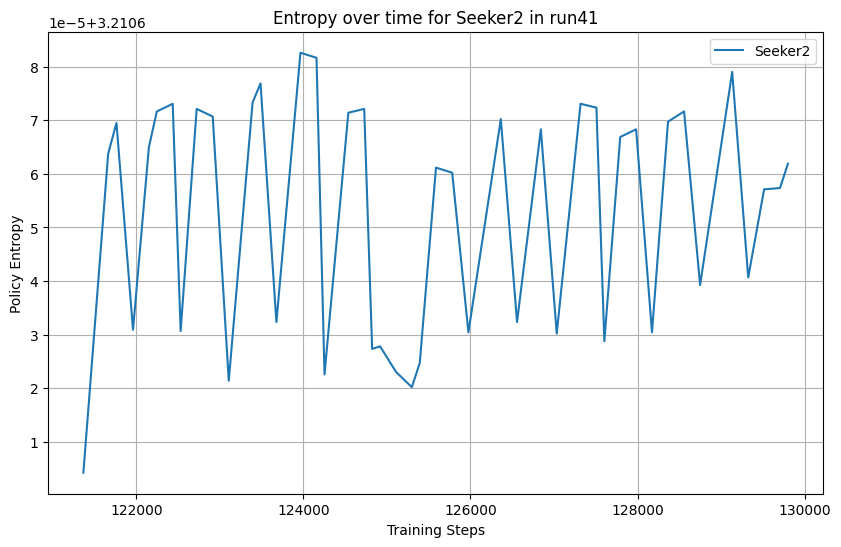

Seeker2 in run41: Early entropy avg: 3.2107, Late entropy avg: 3.2107
  -> Still mostly exploring


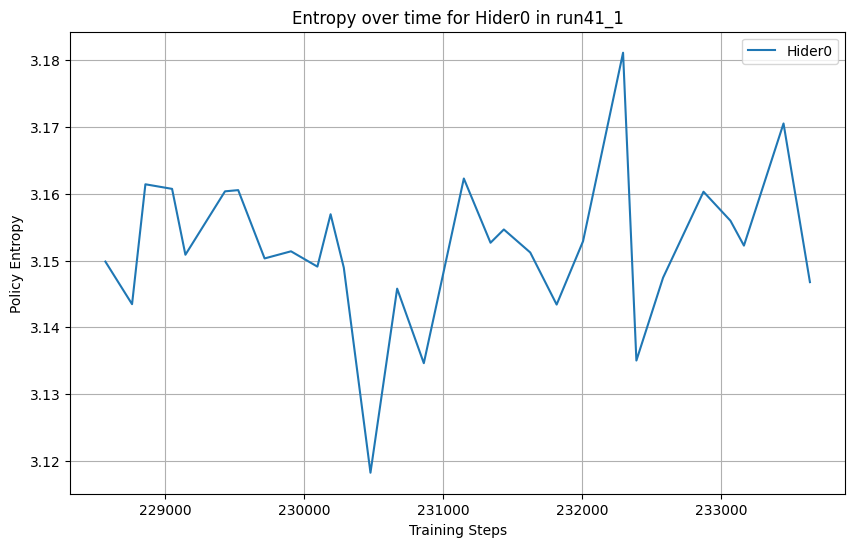

Hider0 in run41_1: Early entropy avg: 3.1538, Late entropy avg: 3.1546
  -> Still mostly exploring


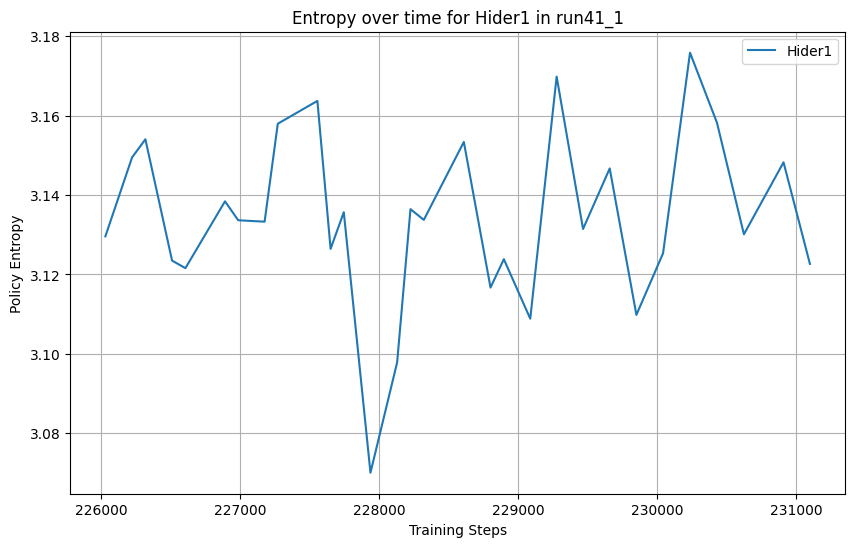

Hider1 in run41_1: Early entropy avg: 3.1405, Late entropy avg: 3.1418
  -> Still mostly exploring


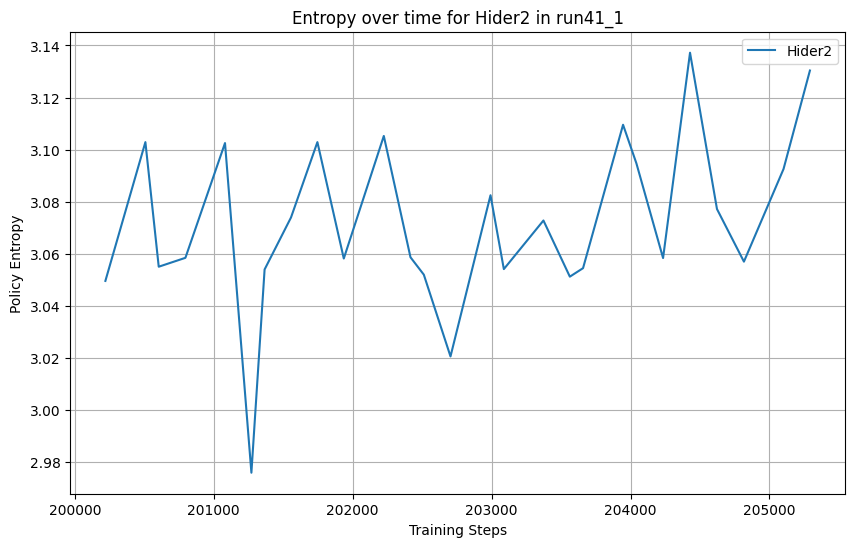

Hider2 in run41_1: Early entropy avg: 3.0633, Late entropy avg: 3.0863
  -> Still mostly exploring


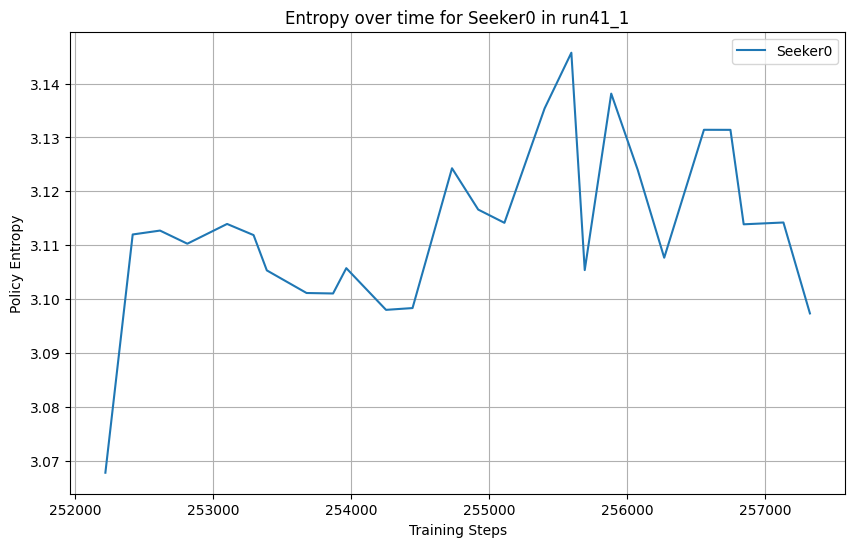

Seeker0 in run41_1: Early entropy avg: 3.1042, Late entropy avg: 3.1209
  -> Still mostly exploring


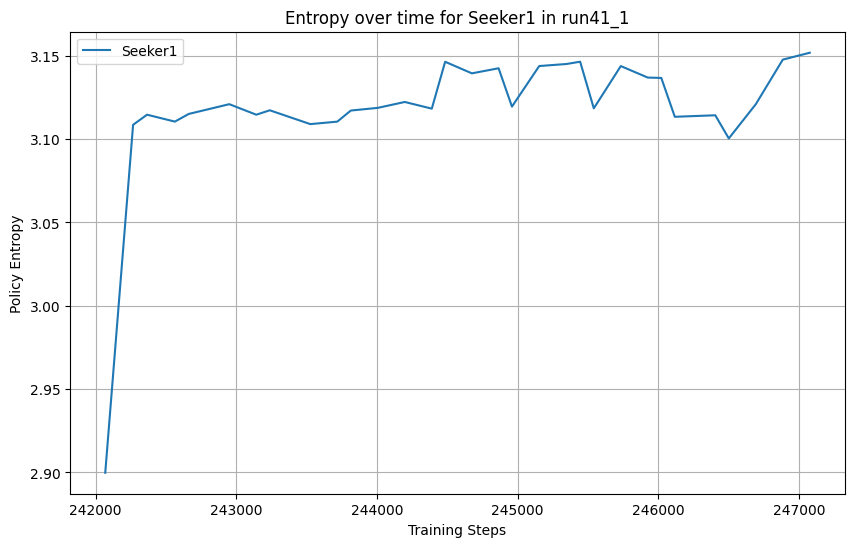

Seeker1 in run41_1: Early entropy avg: 3.0921, Late entropy avg: 3.1285
  -> Still mostly exploring


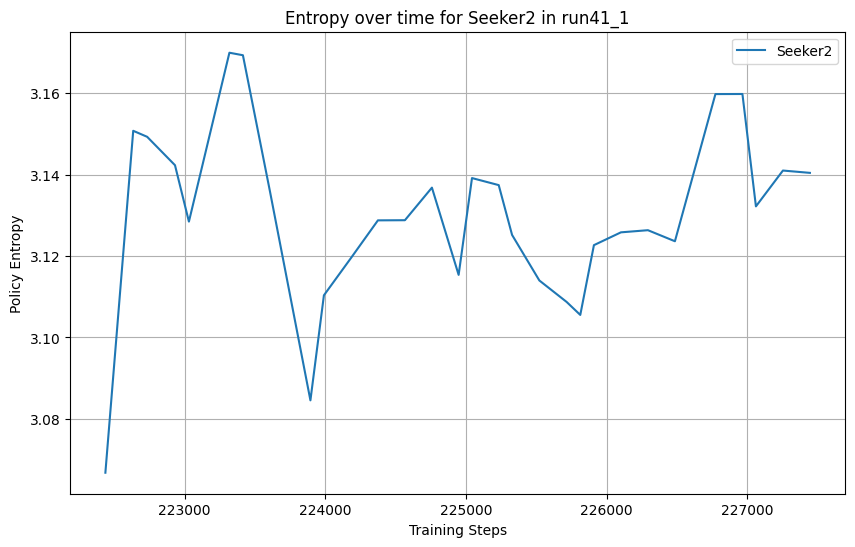

Seeker2 in run41_1: Early entropy avg: 3.1308, Late entropy avg: 3.1337
  -> Still mostly exploring


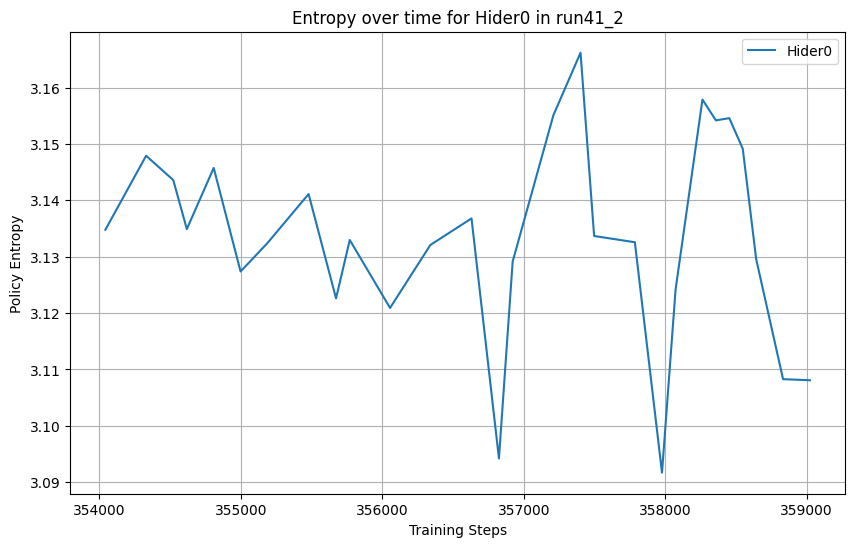

Hider0 in run41_2: Early entropy avg: 3.1363, Late entropy avg: 3.1310
  -> Still mostly exploring


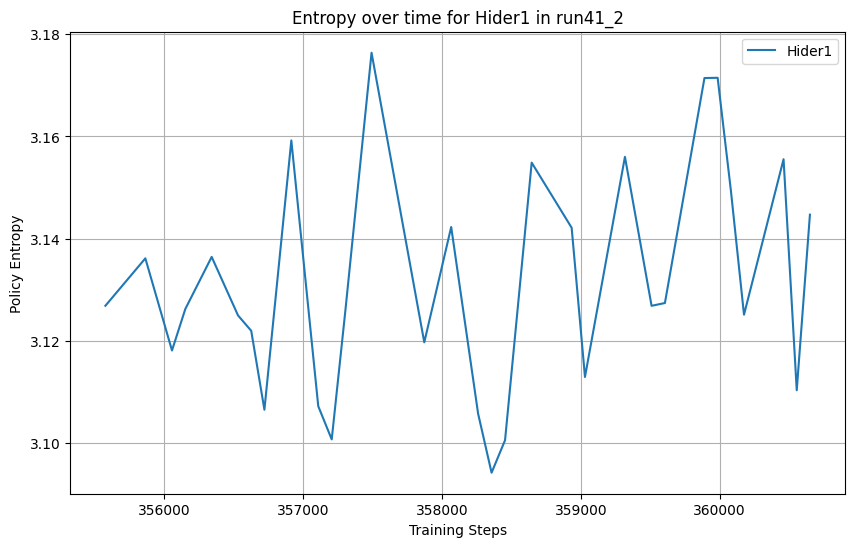

Hider1 in run41_2: Early entropy avg: 3.1264, Late entropy avg: 3.1438
  -> Still mostly exploring


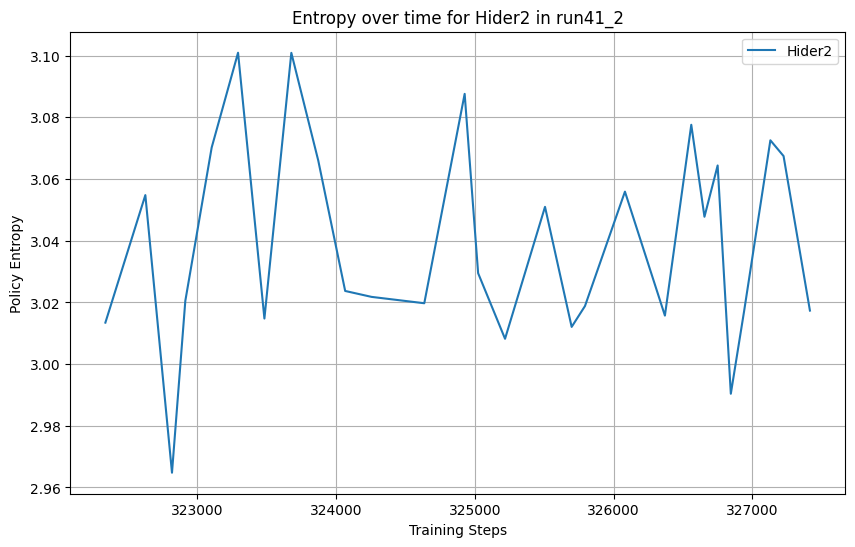

Hider2 in run41_2: Early entropy avg: 3.0430, Late entropy avg: 3.0426
  -> Still mostly exploring


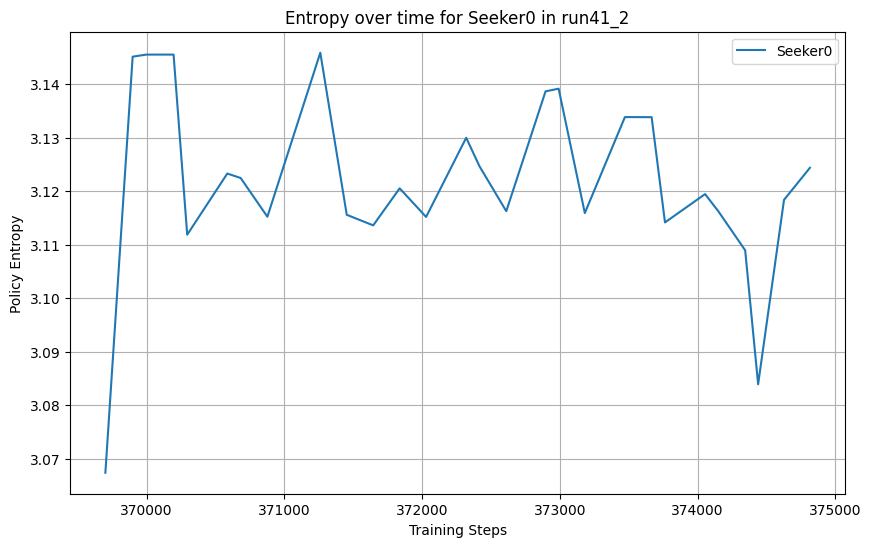

Seeker0 in run41_2: Early entropy avg: 3.1238, Late entropy avg: 3.1169
  -> Still mostly exploring


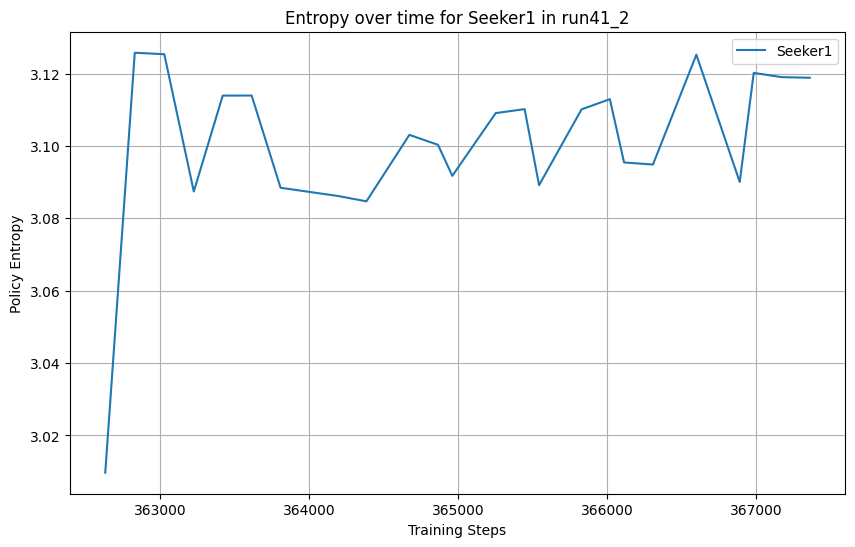

Seeker1 in run41_2: Early entropy avg: 3.0939, Late entropy avg: 3.1076
  -> Still mostly exploring


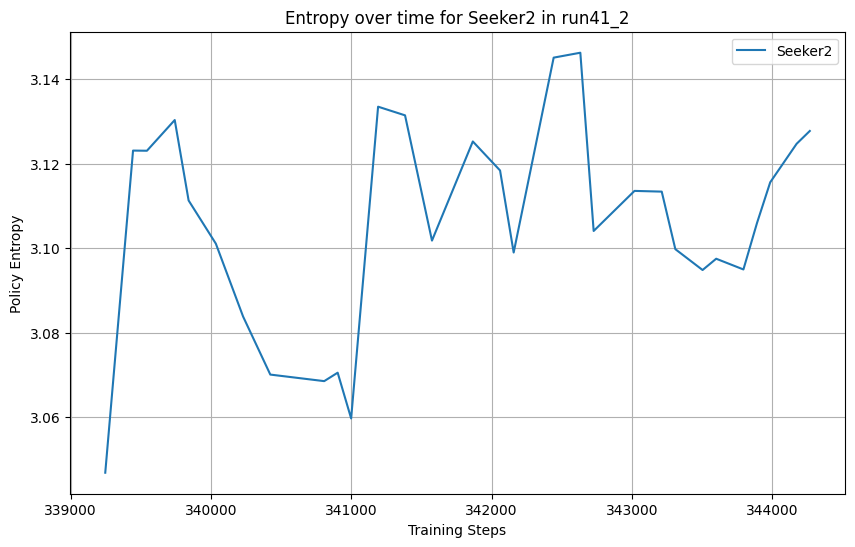

Seeker2 in run41_2: Early entropy avg: 3.0928, Late entropy avg: 3.1088
  -> Still mostly exploring


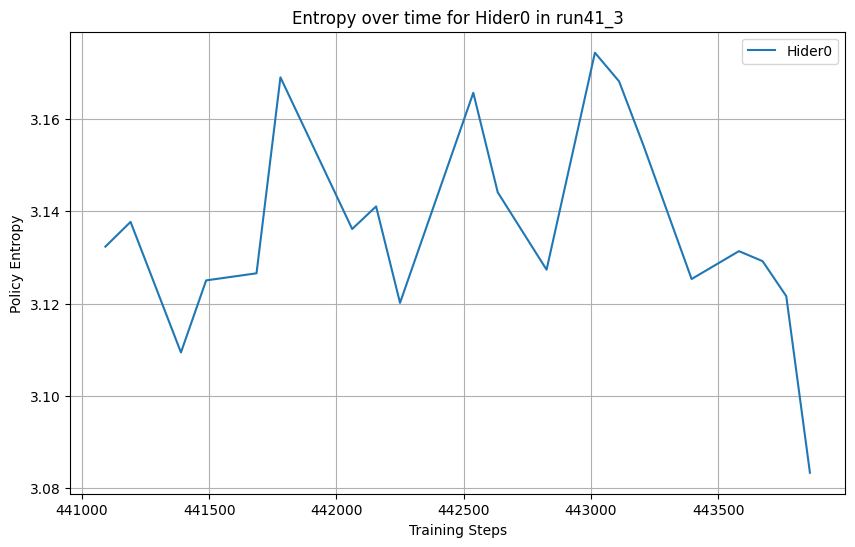

Hider0 in run41_3: Early entropy avg: 3.1363, Late entropy avg: 3.1359
  -> Still mostly exploring


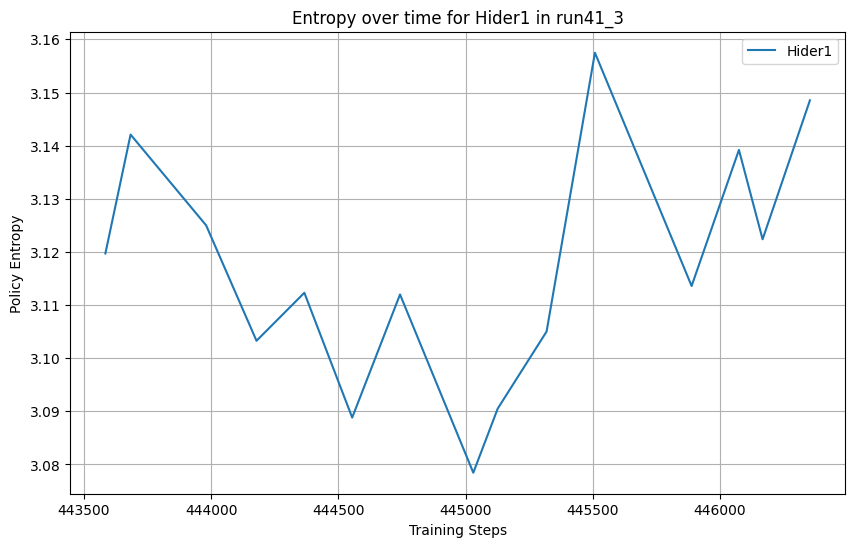

Hider1 in run41_3: Early entropy avg: 3.1077, Late entropy avg: 3.1156
  -> Still mostly exploring


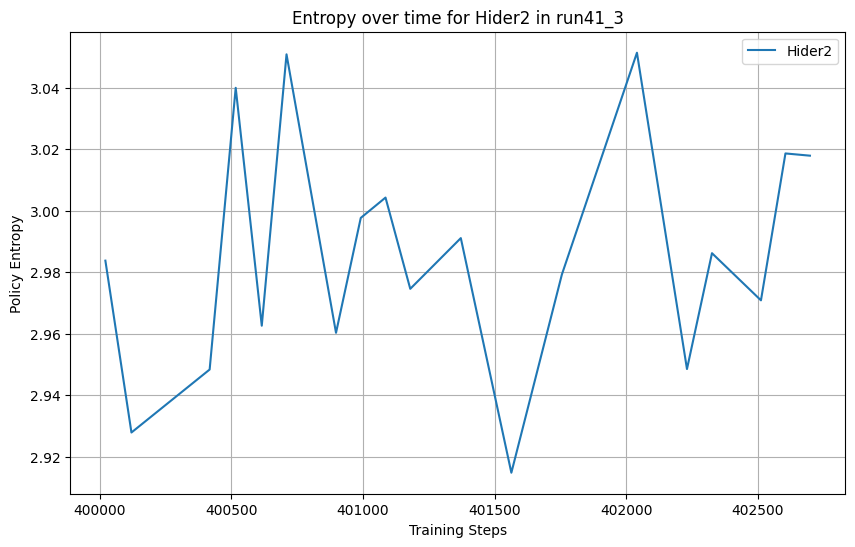

Hider2 in run41_3: Early entropy avg: 2.9850, Late entropy avg: 2.9853
  -> Still mostly exploring


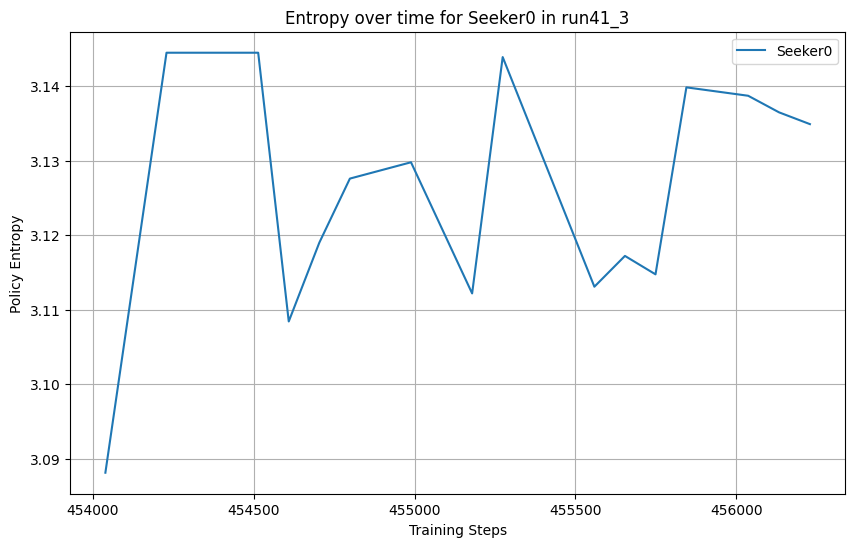

Seeker0 in run41_3: Early entropy avg: 3.1263, Late entropy avg: 3.1281
  -> Still mostly exploring


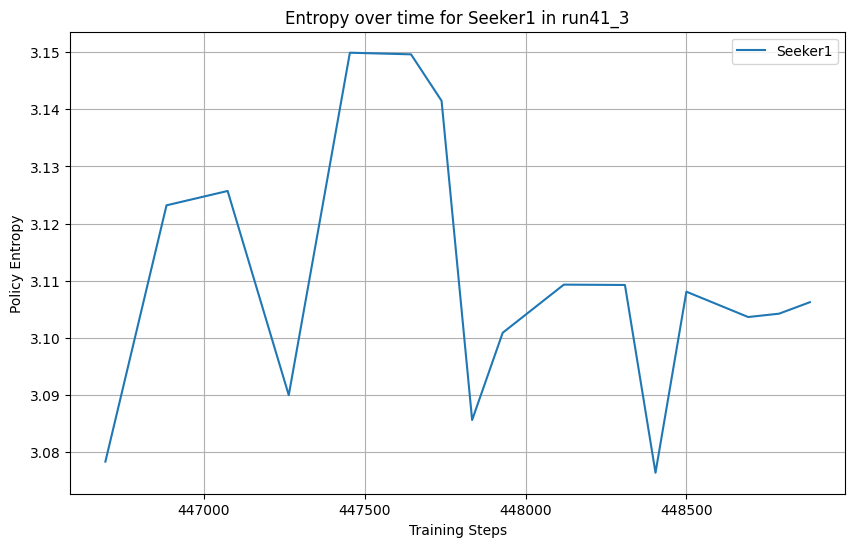

Seeker1 in run41_3: Early entropy avg: 3.1154, Late entropy avg: 3.1045
  -> Still mostly exploring


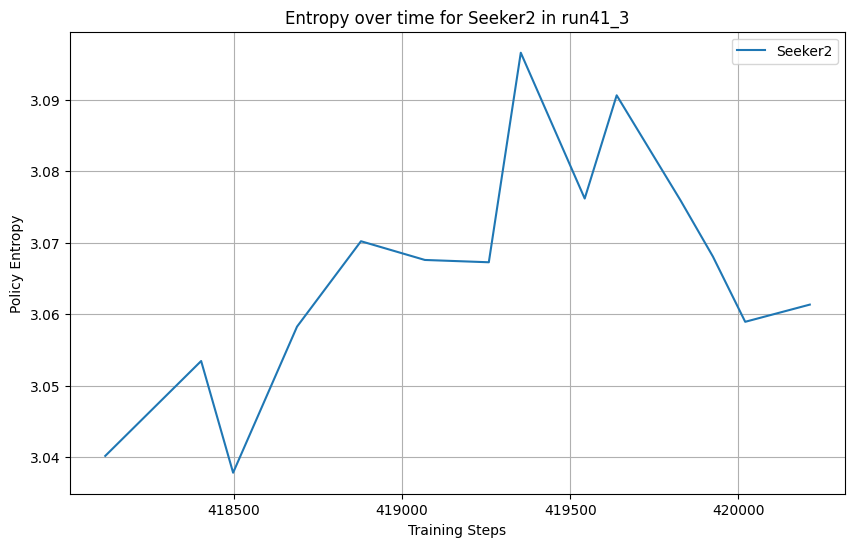

Seeker2 in run41_3: Early entropy avg: 3.0658, Late entropy avg: 3.0733
  -> Still mostly exploring


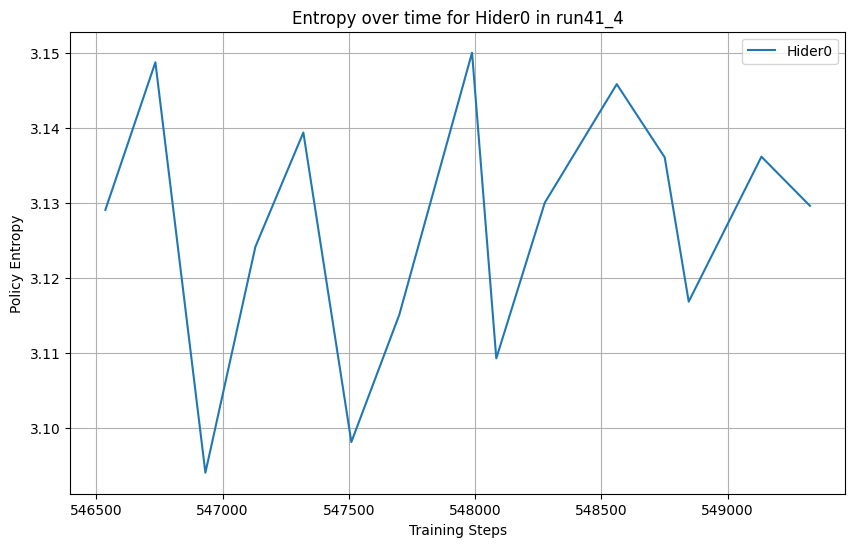

Hider0 in run41_4: Early entropy avg: 3.1238, Late entropy avg: 3.1267
  -> Still mostly exploring


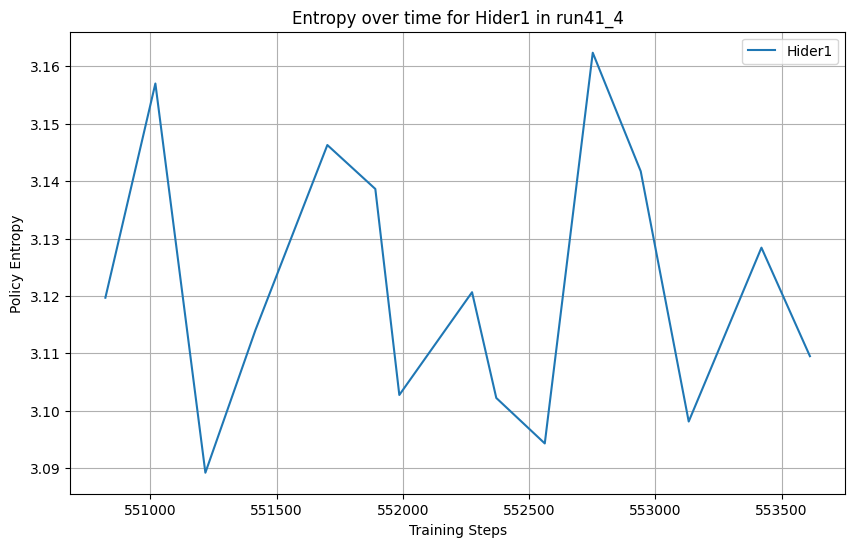

Hider1 in run41_4: Early entropy avg: 3.1185, Late entropy avg: 3.1199
  -> Still mostly exploring


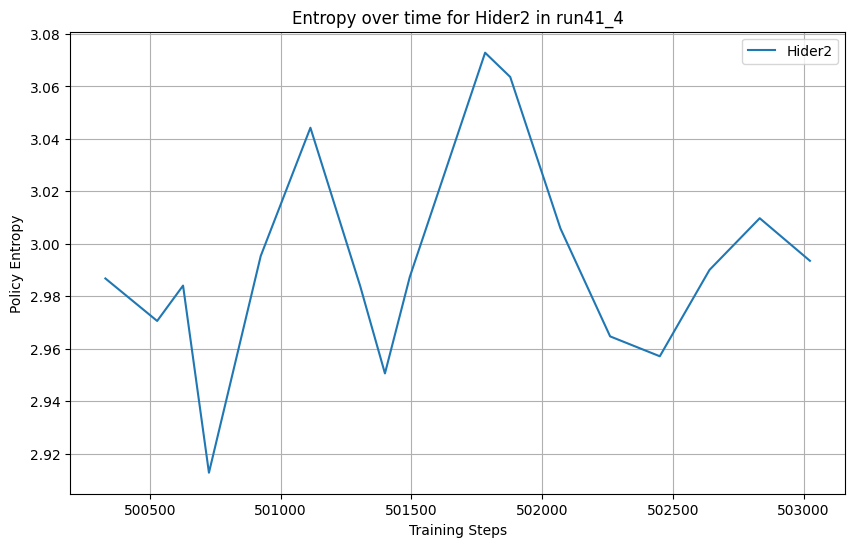

Hider2 in run41_4: Early entropy avg: 2.9889, Late entropy avg: 2.9996
  -> Still mostly exploring


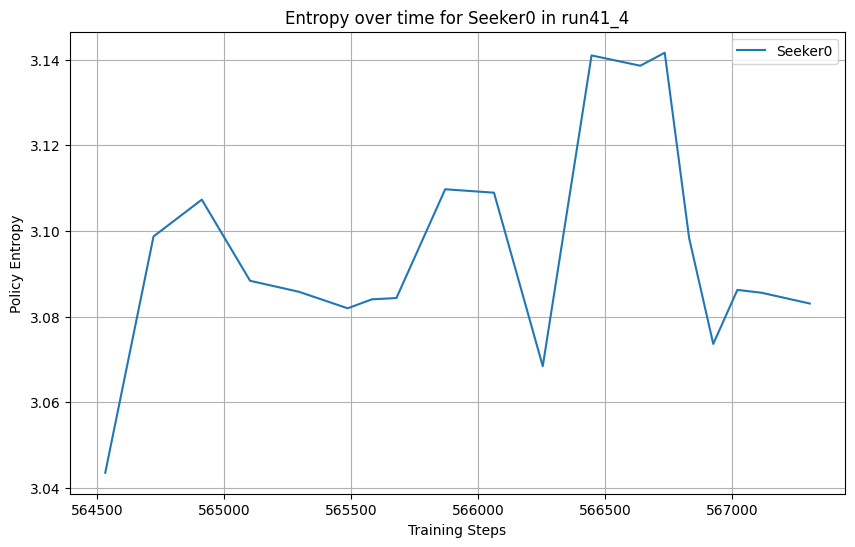

Seeker0 in run41_4: Early entropy avg: 3.0893, Late entropy avg: 3.1025
  -> Still mostly exploring


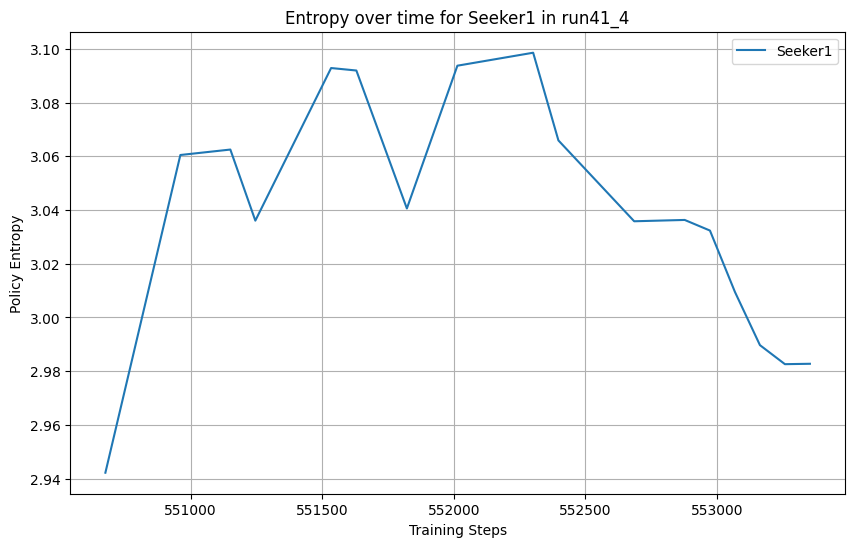

Seeker1 in run41_4: Early entropy avg: 3.0585, Late entropy avg: 3.0327
  -> Still mostly exploring


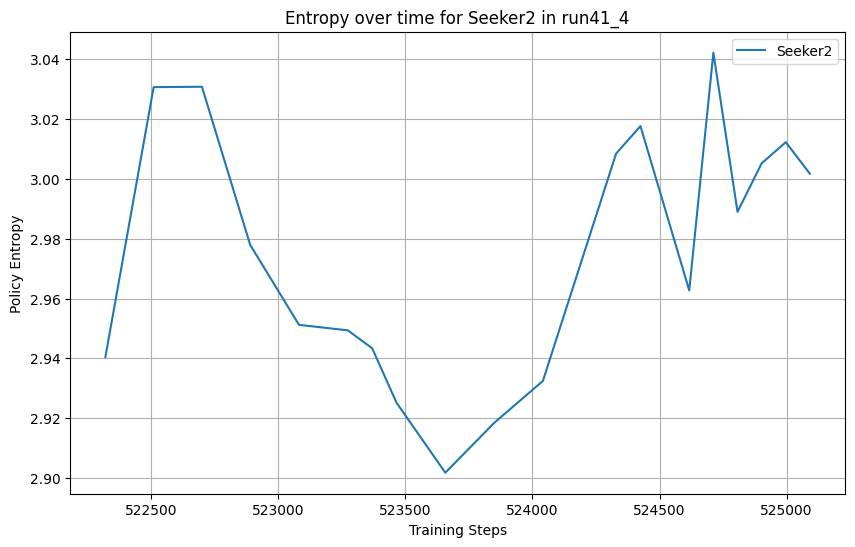

Seeker2 in run41_4: Early entropy avg: 2.9569, Late entropy avg: 2.9890
  -> Still mostly exploring


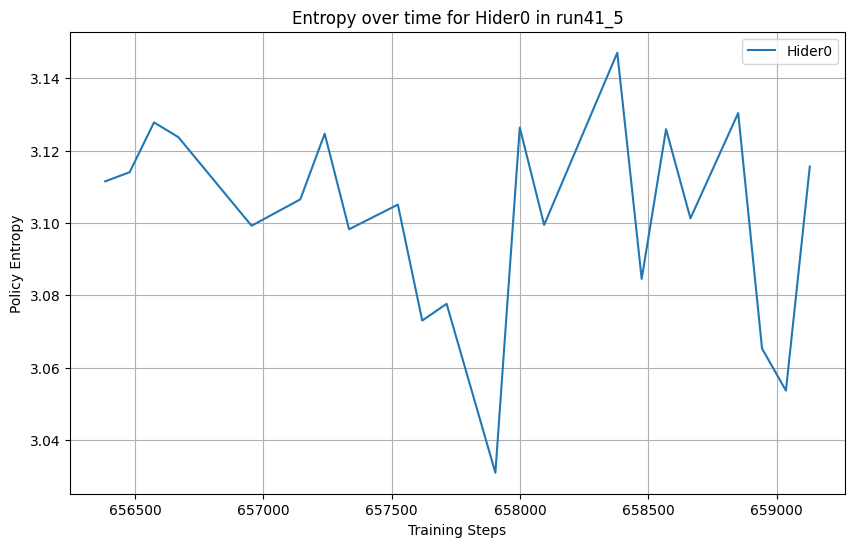

Hider0 in run41_5: Early entropy avg: 3.1084, Late entropy avg: 3.1049
  -> Still mostly exploring


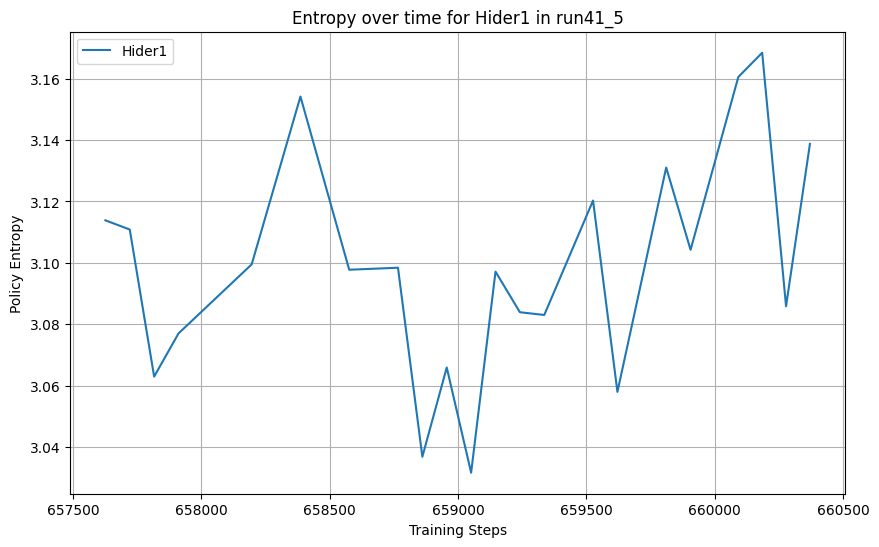

Hider1 in run41_5: Early entropy avg: 3.0917, Late entropy avg: 3.1134
  -> Still mostly exploring


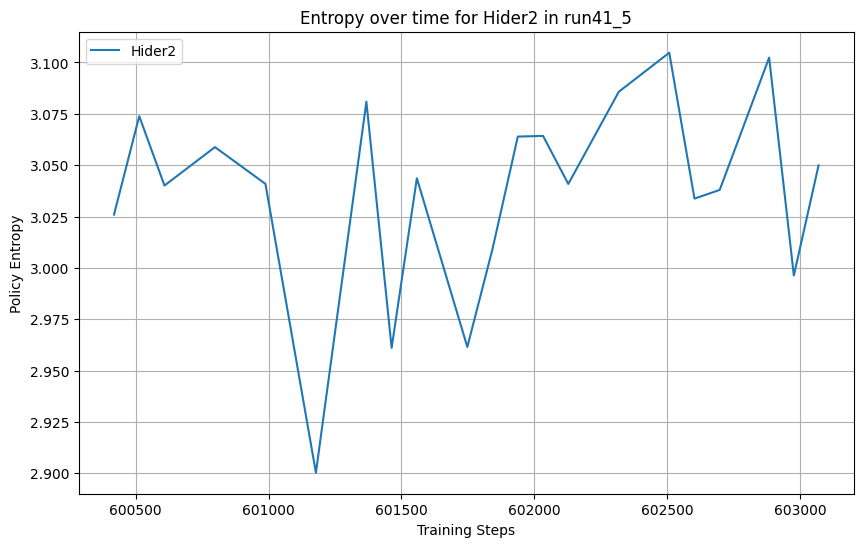

Hider2 in run41_5: Early entropy avg: 3.0187, Late entropy avg: 3.0579
  -> Still mostly exploring


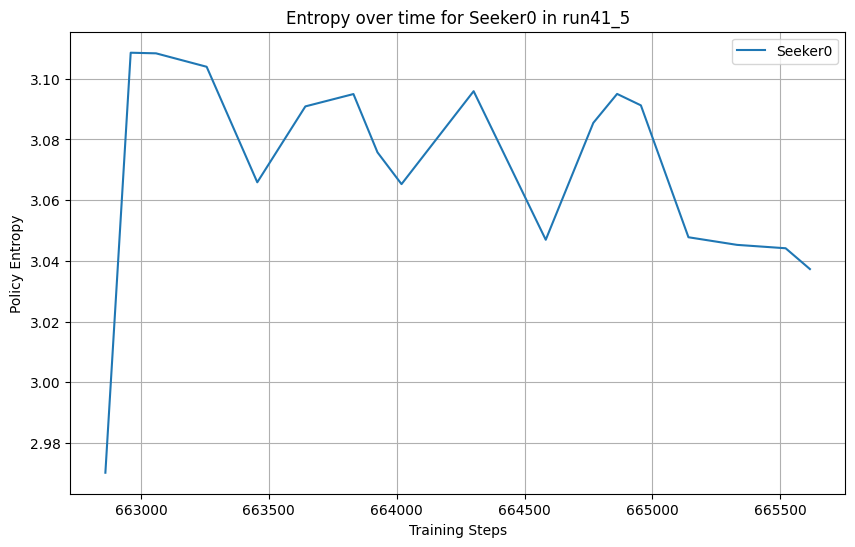

Seeker0 in run41_5: Early entropy avg: 3.0780, Late entropy avg: 3.0654
  -> Still mostly exploring


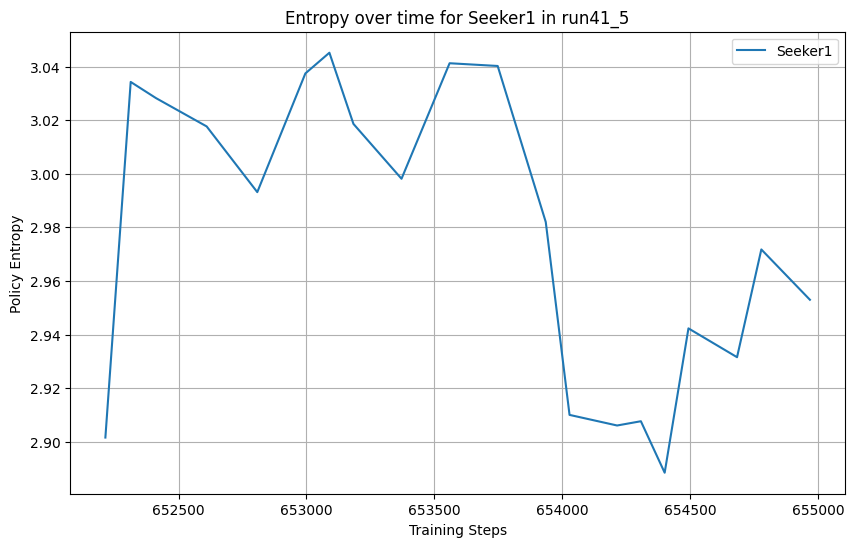

Seeker1 in run41_5: Early entropy avg: 3.0116, Late entropy avg: 2.9433
  -> Still mostly exploring


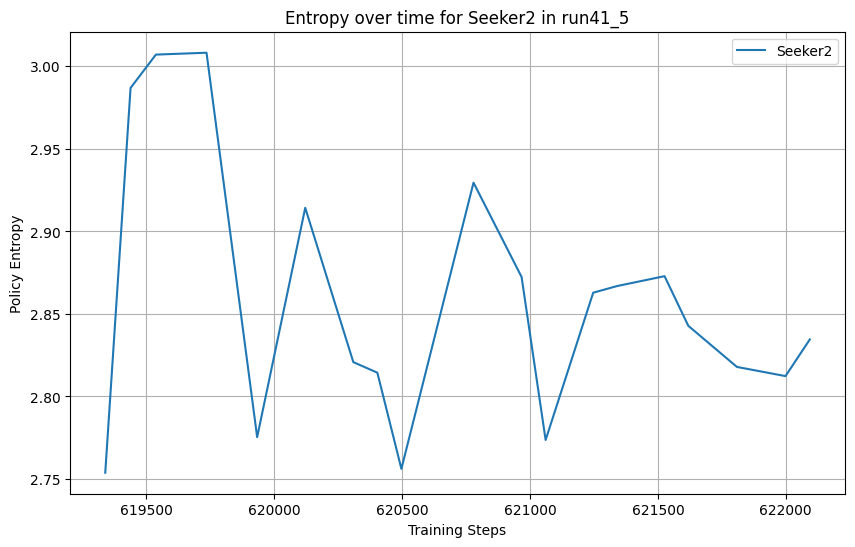

Seeker2 in run41_5: Early entropy avg: 2.8767, Late entropy avg: 2.8486
  -> Still mostly exploring


In [4]:
# Plot entropy over time for each agent
for run_name, agents_data in data.items():
    for agent, metrics in agents_data.items():
        if metrics and metrics['entropy']:
            steps, entropies = zip(*metrics['entropy'])
            plt.figure(figsize=(10, 6))
            plt.plot(steps, entropies, label=f'{agent}')
            plt.title(f'Entropy over time for {agent} in {run_name}')
            plt.xlabel('Training Steps')
            plt.ylabel('Policy Entropy')
            plt.grid(True)
            plt.legend()
            plt.show()
            
            # Insight: Shift occurs when entropy starts decreasing significantly
            if len(entropies) > 10:
                early_avg = np.mean(entropies[:10])
                late_avg = np.mean(entropies[-10:])
                print(f'{agent} in {run_name}: Early entropy avg: {early_avg:.4f}, Late entropy avg: {late_avg:.4f}')
                if late_avg < early_avg * 0.5:
                    print('  -> Clear shift from exploration to exploitation')
                elif late_avg < early_avg * 0.8:
                    print('  -> Gradual shift')
                else:
                    print('  -> Still mostly exploring')

### 2. How often actions repeated vs changed

This requires logging actions during training. Since actions aren't logged in TensorBoard by default, we can look at policy loss or entropy as proxies.

High entropy suggests more varied actions (exploration), low entropy suggests repeated similar actions (exploitation).

In [5]:
# Analyze action diversity through entropy
for run_name, agents_data in data.items():
    for agent, metrics in agents_data.items():
        if metrics and metrics['entropy']:
            entropies = [e for s, e in metrics['entropy']]
            avg_entropy = np.mean(entropies)
            entropy_std = np.std(entropies)
            print(f'{agent} in {run_name}: Avg Entropy: {avg_entropy:.4f}, Std: {entropy_std:.4f}')
            if avg_entropy > 1.0:
                print('  -> High action diversity (exploration)')
            elif avg_entropy > 0.5:
                print('  -> Moderate action diversity')
            else:
                print('  -> Low action diversity (exploitation, repeated actions)')

Hider0 in run41: Avg Entropy: 3.2106, Std: 0.0000
  -> High action diversity (exploration)
Hider1 in run41: Avg Entropy: 3.2071, Std: 0.0009
  -> High action diversity (exploration)
Hider2 in run41: Avg Entropy: 3.2075, Std: 0.0012
  -> High action diversity (exploration)
Seeker0 in run41: Avg Entropy: 3.1922, Std: 0.0049
  -> High action diversity (exploration)
Seeker1 in run41: Avg Entropy: 3.1963, Std: 0.0059
  -> High action diversity (exploration)
Seeker2 in run41: Avg Entropy: 3.2107, Std: 0.0000
  -> High action diversity (exploration)
Hider0 in run41_1: Avg Entropy: 3.1520, Std: 0.0113
  -> High action diversity (exploration)
Hider1 in run41_1: Avg Entropy: 3.1342, Std: 0.0217
  -> High action diversity (exploration)
Hider2 in run41_1: Avg Entropy: 3.0719, Std: 0.0331
  -> High action diversity (exploration)
Seeker0 in run41_1: Avg Entropy: 3.1128, Std: 0.0154
  -> High action diversity (exploration)
Seeker1 in run41_1: Avg Entropy: 3.1183, Std: 0.0424
  -> High action diversit

### 3. Whether exploration reduced too early

Compare entropy decrease with reward improvement. If entropy drops before rewards stabilize, exploration might have reduced too early.

In [6]:
# Compare entropy and reward trends
for run_name, agents_data in data.items():
    for agent, metrics in agents_data.items():
        if metrics and metrics['entropy'] and metrics['reward']:
            ent_steps, entropies = zip(*metrics['entropy'])
            rew_steps, rewards = zip(*metrics['reward'])
            
            # Simple check: when entropy drops below threshold vs reward stability
            ent_threshold = np.mean(entropies) * 0.3
            low_ent_step = next((s for s, e in zip(ent_steps, entropies) if e < ent_threshold), None)
            
            if low_ent_step:
                # Check reward at that step
                reward_at_low_ent = next((r for s, r in zip(rew_steps, rewards) if s >= low_ent_step), rewards[-1])
                final_reward = rewards[-1]
                reward_ratio = reward_at_low_ent / final_reward if final_reward != 0 else 1
                
                print(f'{agent} in {run_name}: Entropy dropped at step {low_ent_step}, reward ratio: {reward_ratio:.2f}')
                if reward_ratio < 0.8:
                    print('  -> Exploration might have reduced too early (reward still improving)')
                else:
                    print('  -> Exploration reduced appropriately')

## Reward Decomposition Study

### 1. Break down reward contributions

From the code, rewards have components: VisibilityIndividual, VisibilityTeam, Capture, OobPenalty.

Since individual components aren't logged, we can only analyze cumulative rewards.

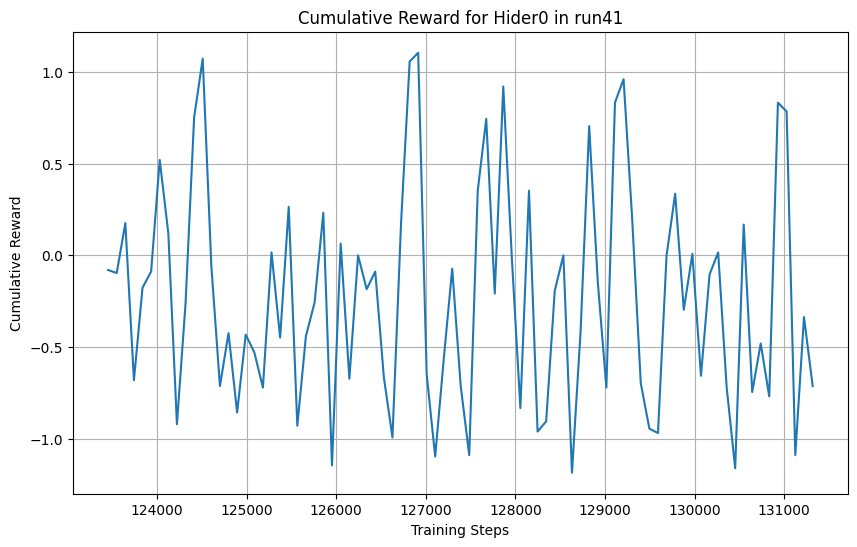

Hider0 in run41: Reward improvement: -0.2016
  -> Rewards not improving


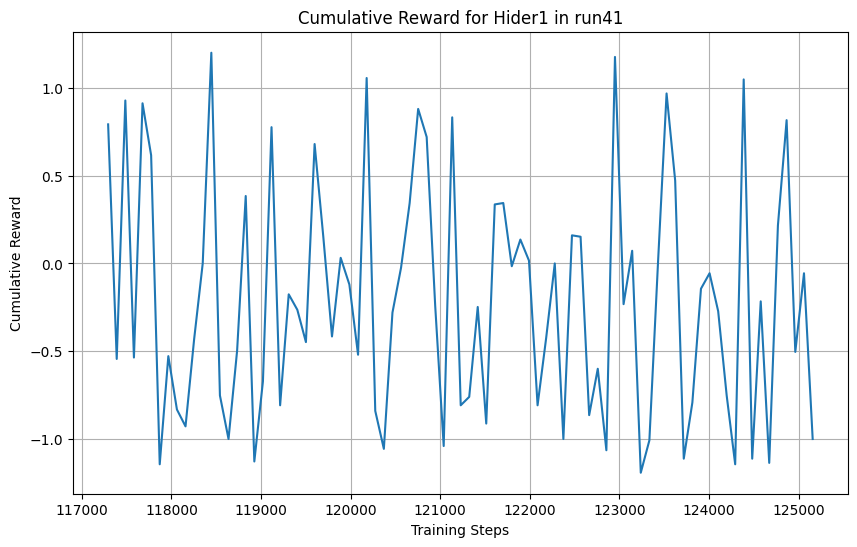

Hider1 in run41: Reward improvement: -0.1824
  -> Rewards not improving


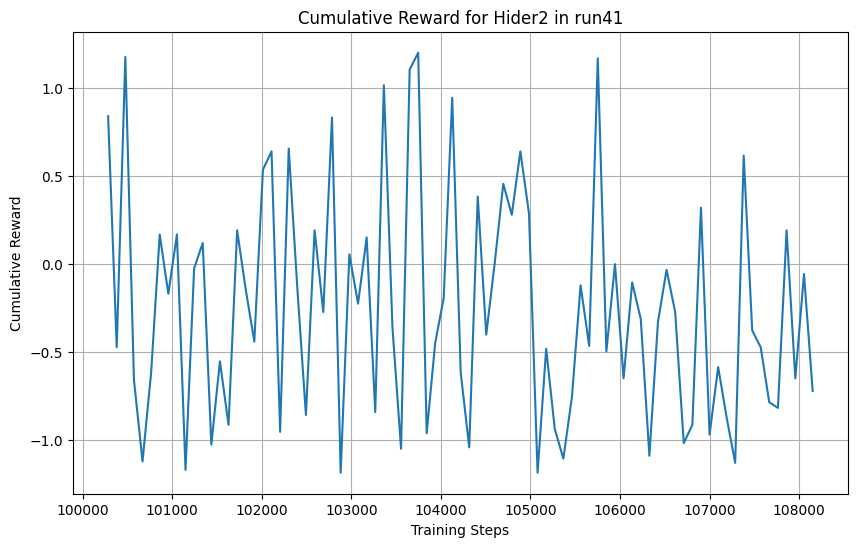

Hider2 in run41: Reward improvement: -0.2344
  -> Rewards not improving


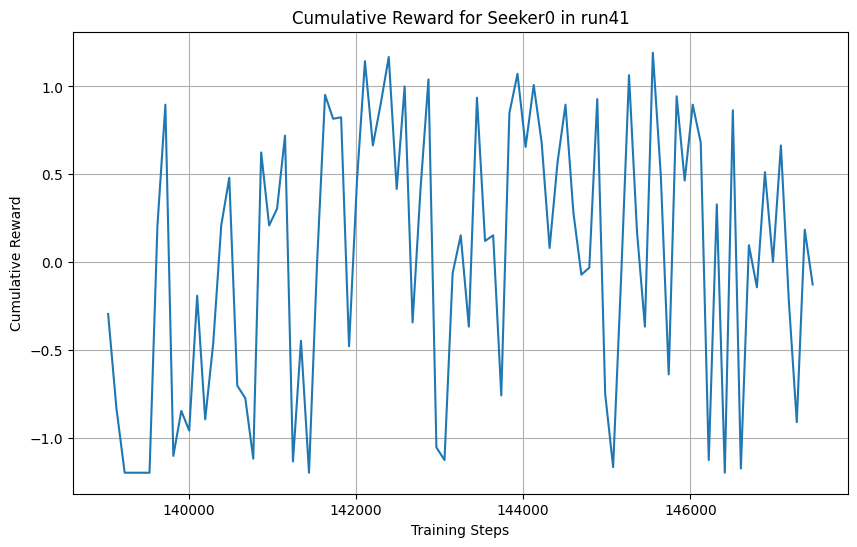

Seeker0 in run41: Reward improvement: 0.5648
  -> Learning positive rewards


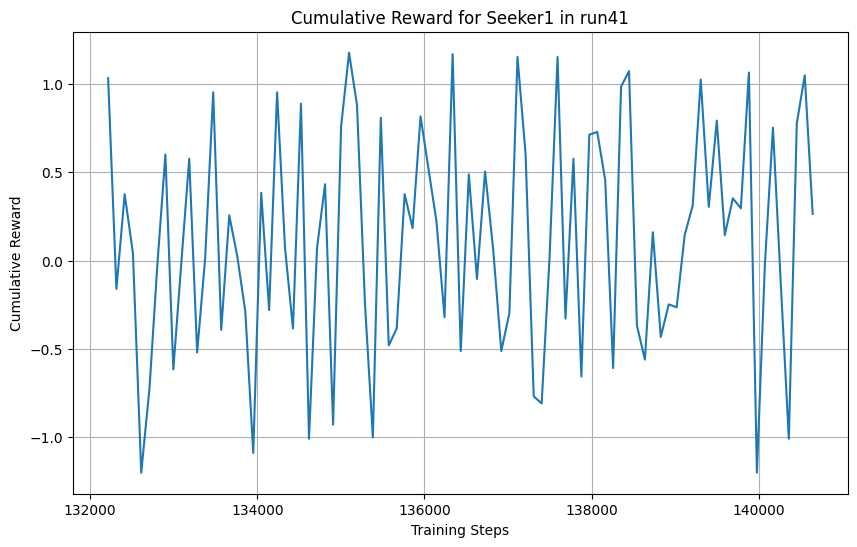

Seeker1 in run41: Reward improvement: 0.2512
  -> Learning positive rewards


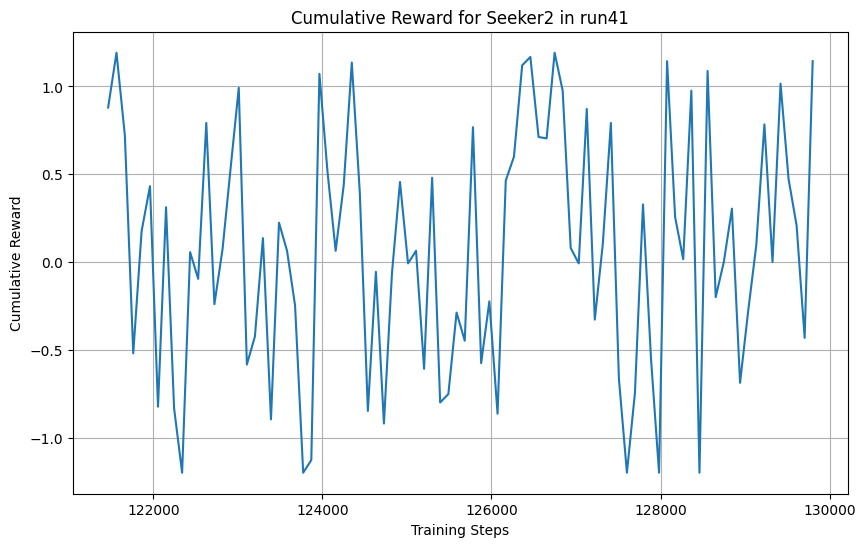

Seeker2 in run41: Reward improvement: 0.1984
  -> Learning positive rewards


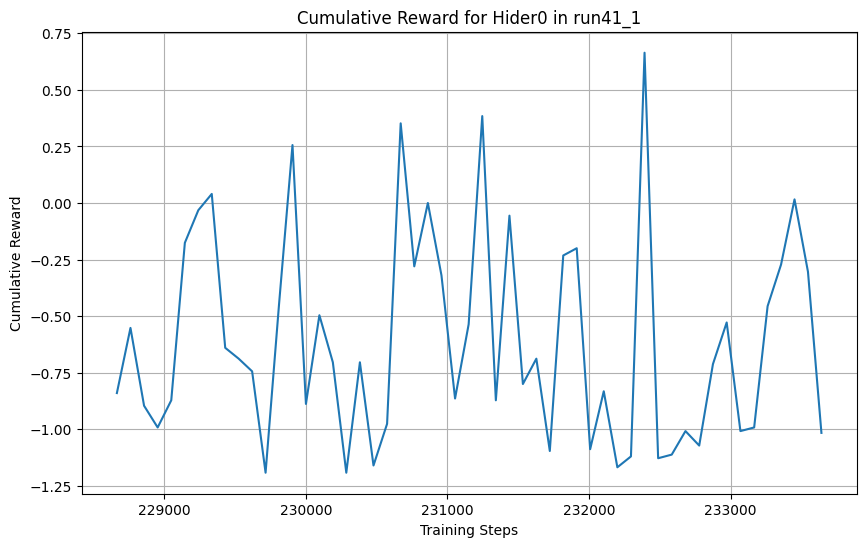

Hider0 in run41_1: Reward improvement: -0.0696
  -> Rewards not improving


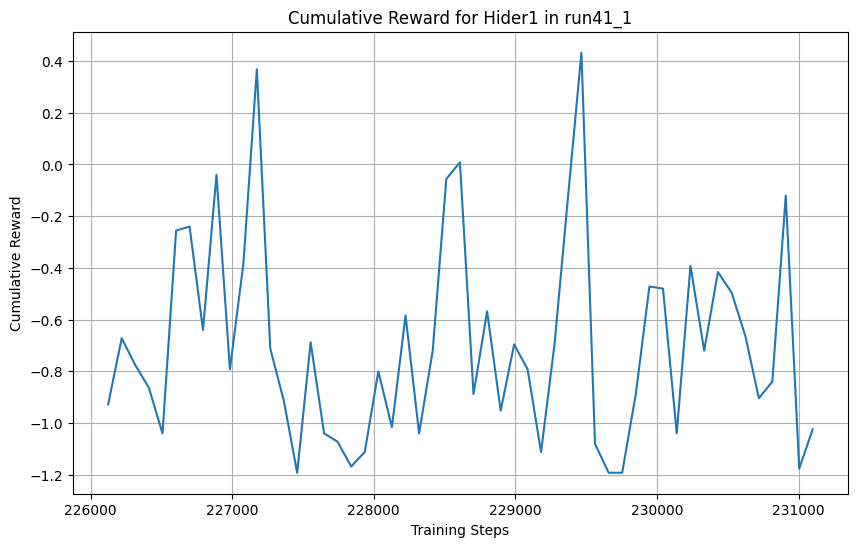

Hider1 in run41_1: Reward improvement: -0.0504
  -> Rewards not improving


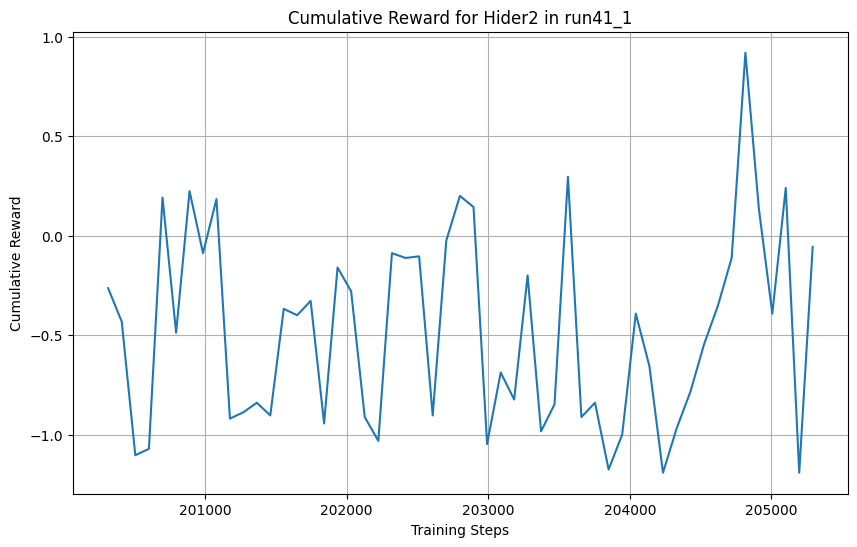

Hider2 in run41_1: Reward improvement: 0.1632
  -> Learning positive rewards


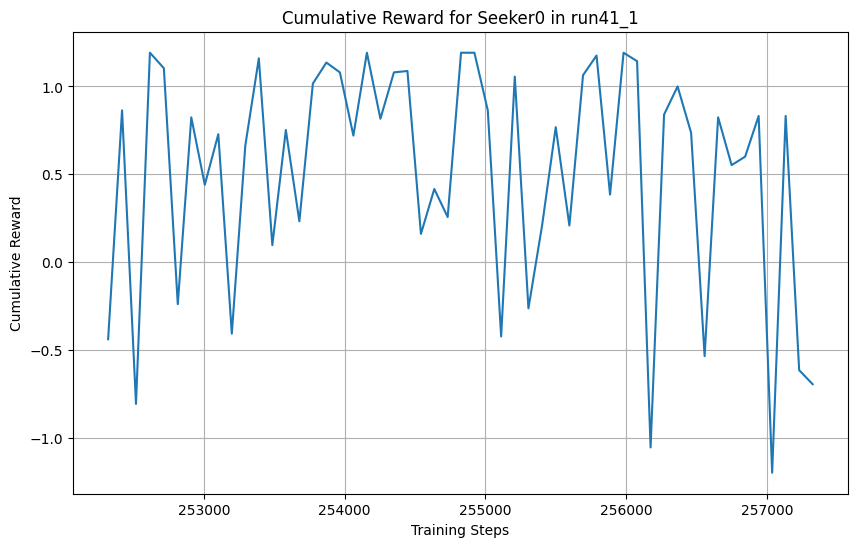

Seeker0 in run41_1: Reward improvement: -0.1928
  -> Rewards not improving


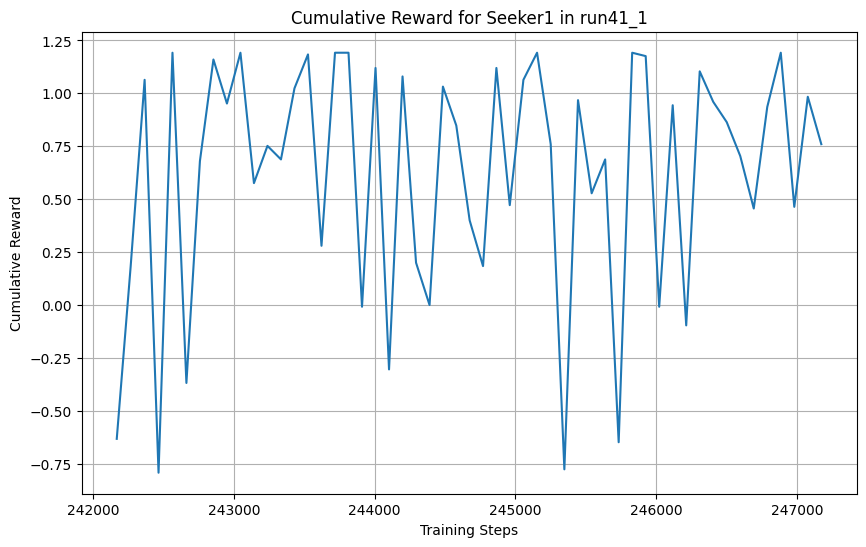

Seeker1 in run41_1: Reward improvement: 0.3792
  -> Learning positive rewards


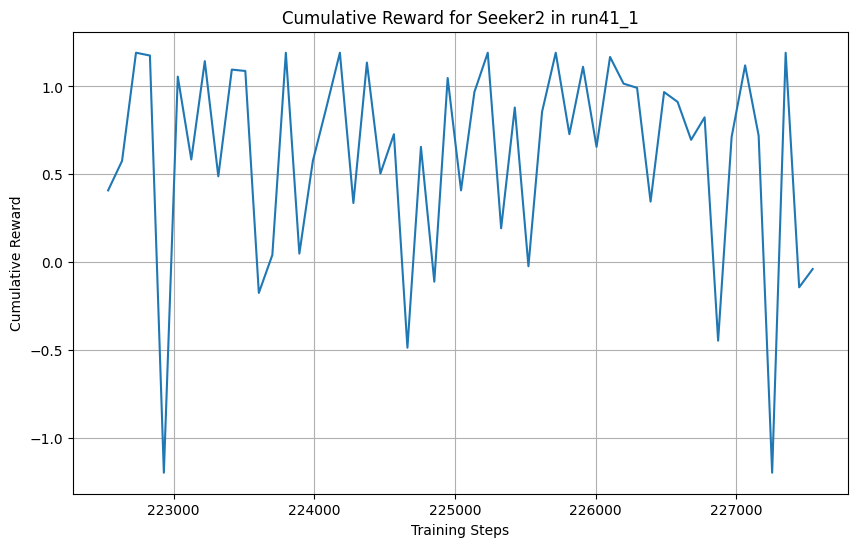

Seeker2 in run41_1: Reward improvement: -0.3088
  -> Rewards not improving


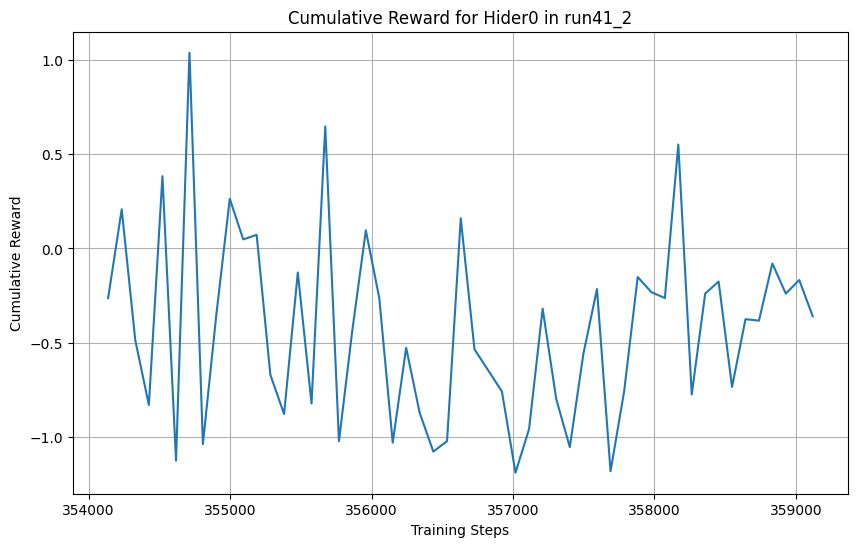

Hider0 in run41_2: Reward improvement: -0.1328
  -> Rewards not improving


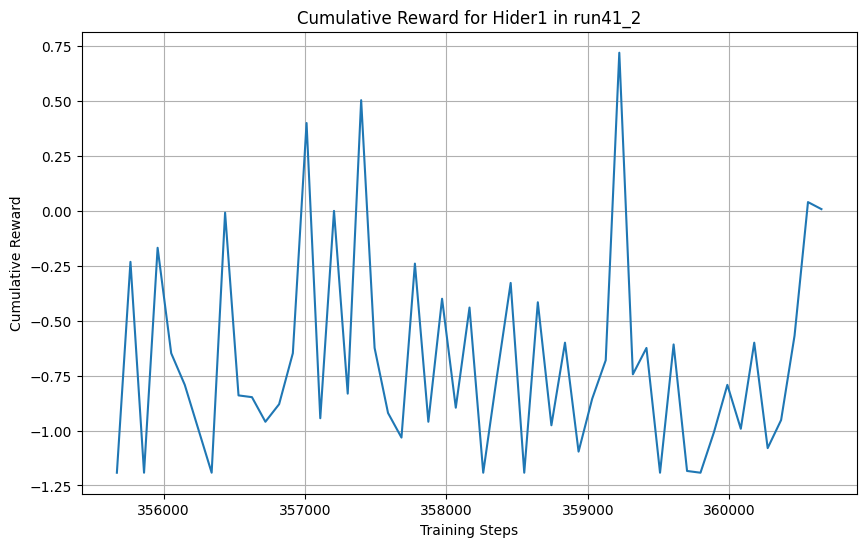

Hider1 in run41_2: Reward improvement: 0.0120
  -> Learning positive rewards


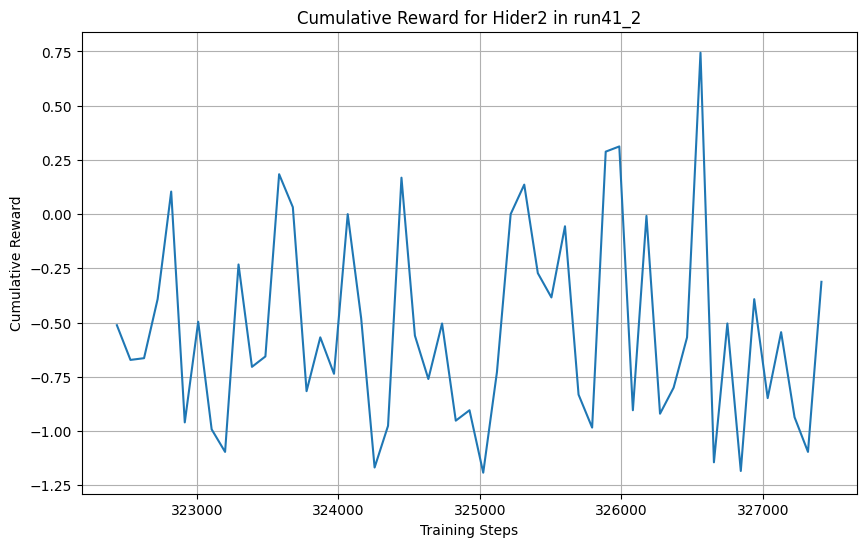

Hider2 in run41_2: Reward improvement: -0.0304
  -> Rewards not improving


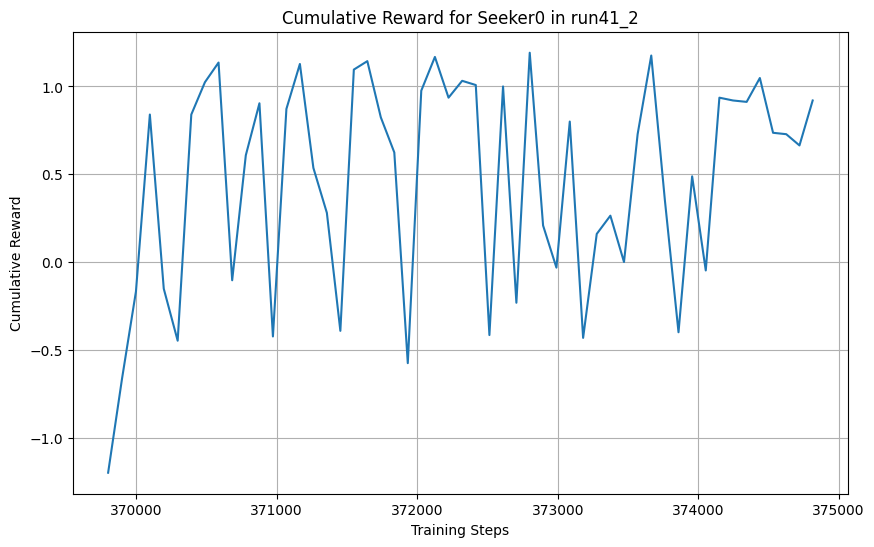

Seeker0 in run41_2: Reward improvement: 0.6200
  -> Learning positive rewards


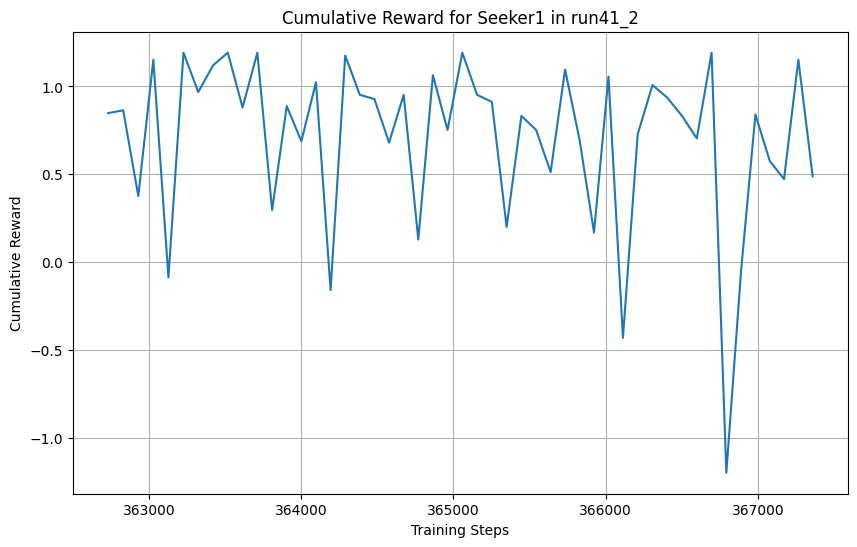

Seeker1 in run41_2: Reward improvement: -0.3496
  -> Rewards not improving


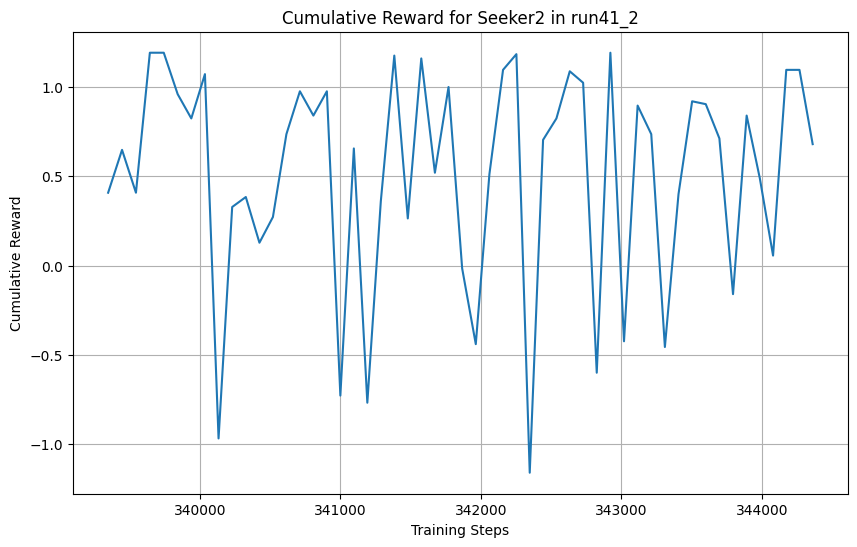

Seeker2 in run41_2: Reward improvement: 0.0568
  -> Learning positive rewards


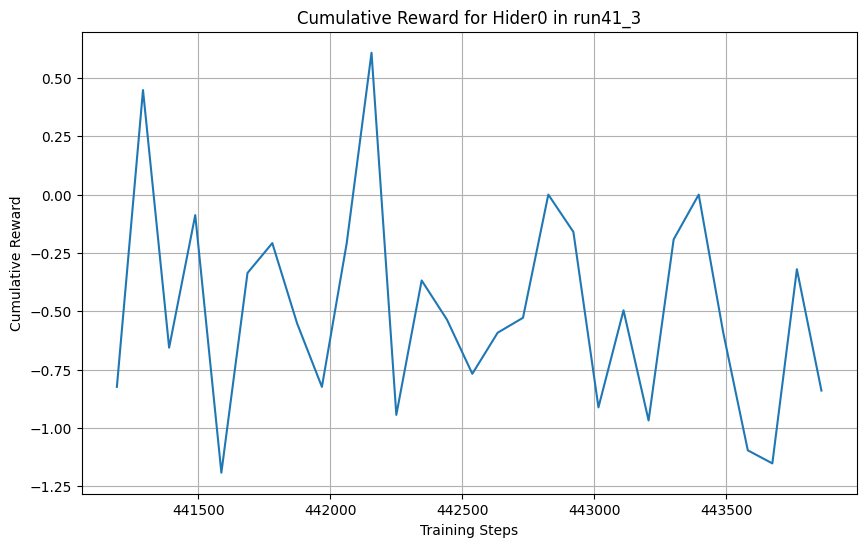

Hider0 in run41_3: Reward improvement: -0.2128
  -> Rewards not improving


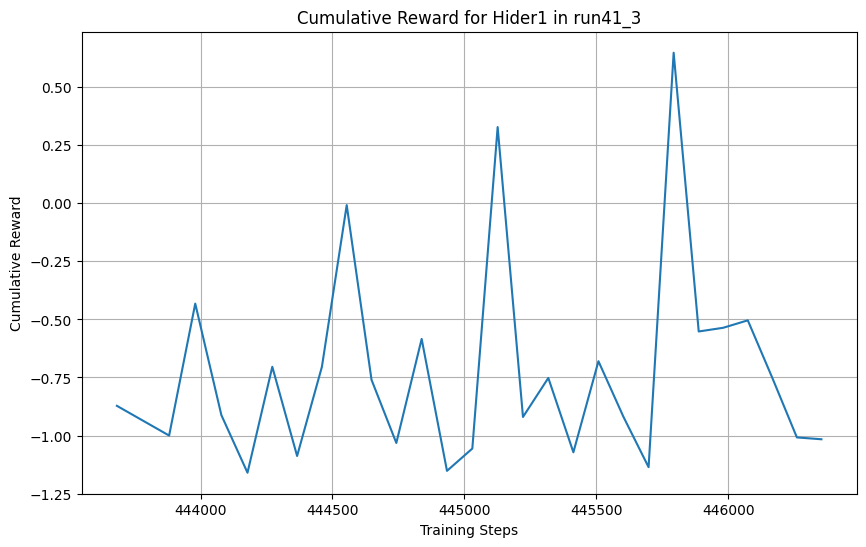

Hider1 in run41_3: Reward improvement: 0.1360
  -> Learning positive rewards


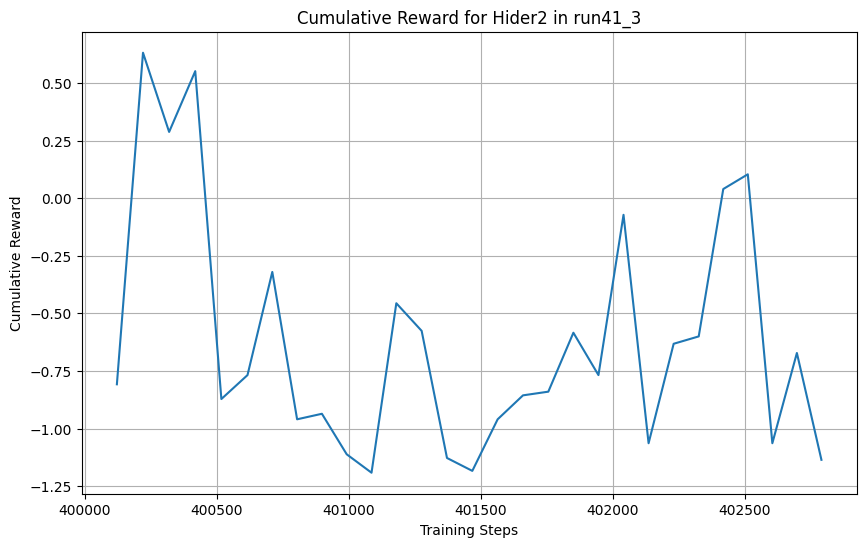

Hider2 in run41_3: Reward improvement: -0.1560
  -> Rewards not improving


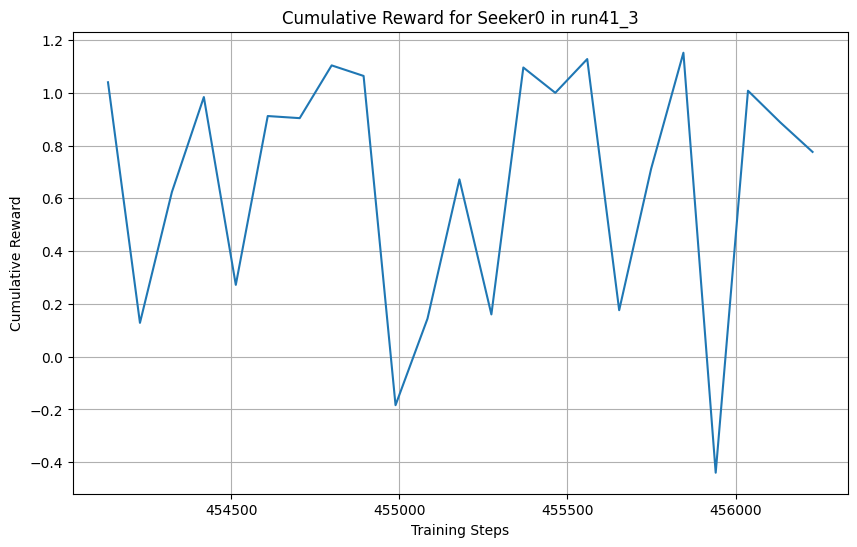

Seeker0 in run41_3: Reward improvement: 0.0648
  -> Learning positive rewards


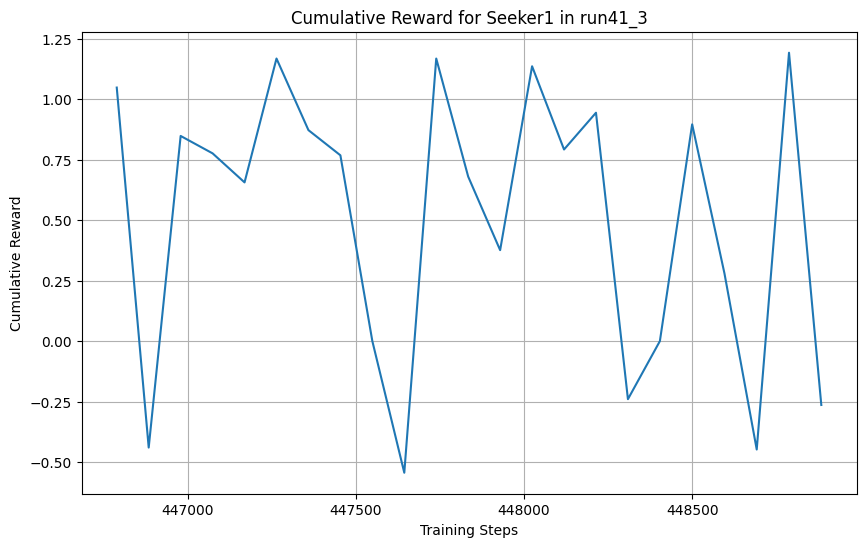

Seeker1 in run41_3: Reward improvement: -0.0864
  -> Rewards not improving


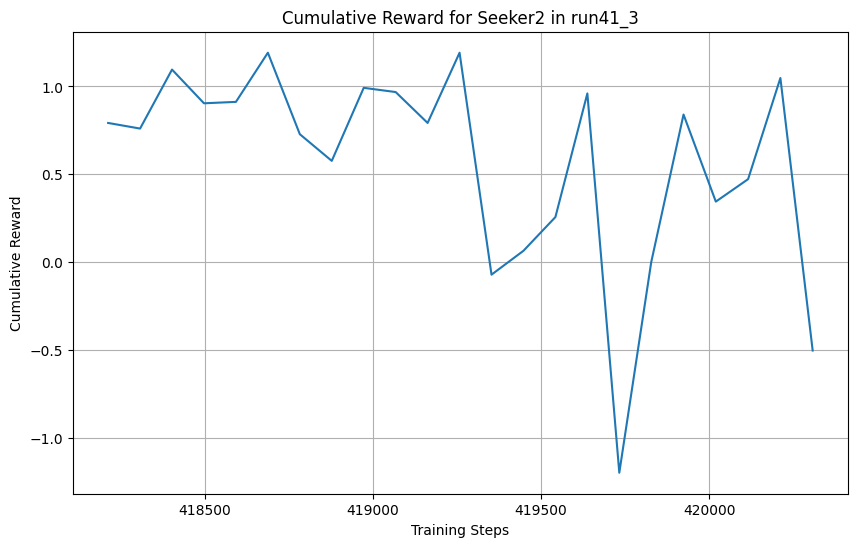

Seeker2 in run41_3: Reward improvement: -0.6640
  -> Rewards not improving


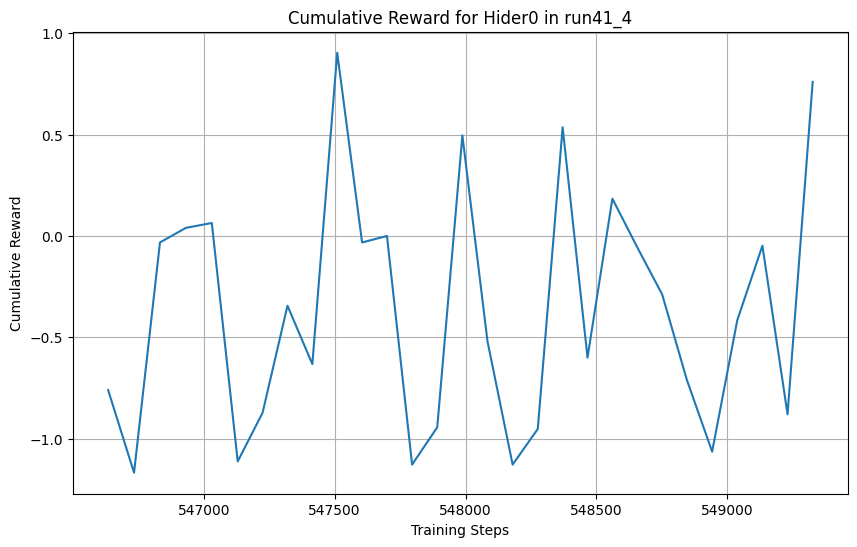

Hider0 in run41_4: Reward improvement: 0.0792
  -> Learning positive rewards


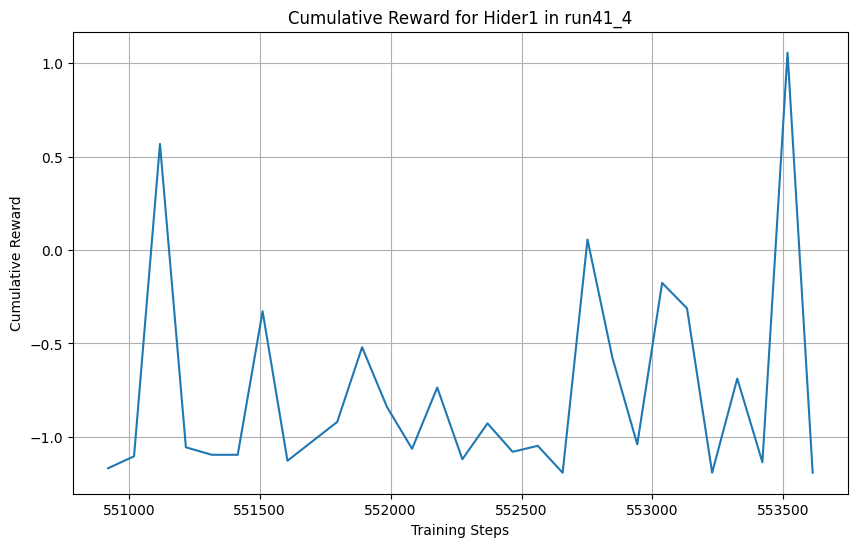

Hider1 in run41_4: Reward improvement: 0.3152
  -> Learning positive rewards


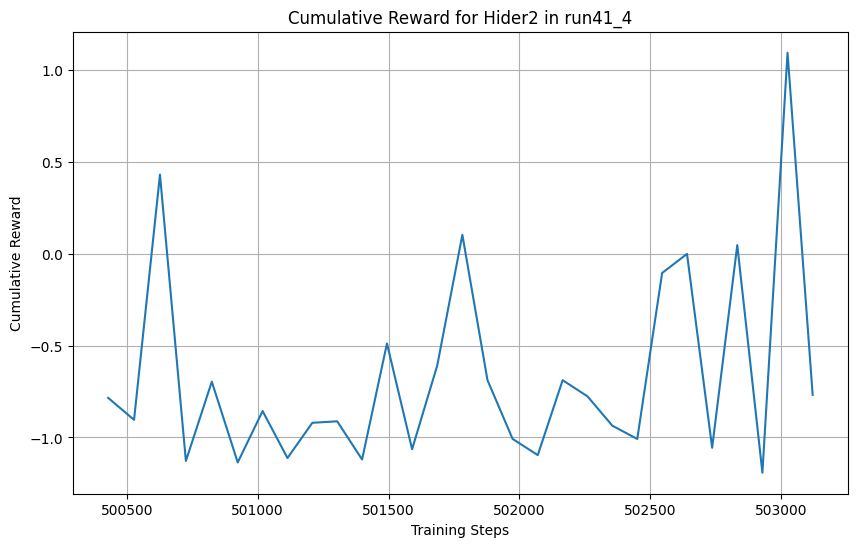

Hider2 in run41_4: Reward improvement: 0.3320
  -> Learning positive rewards


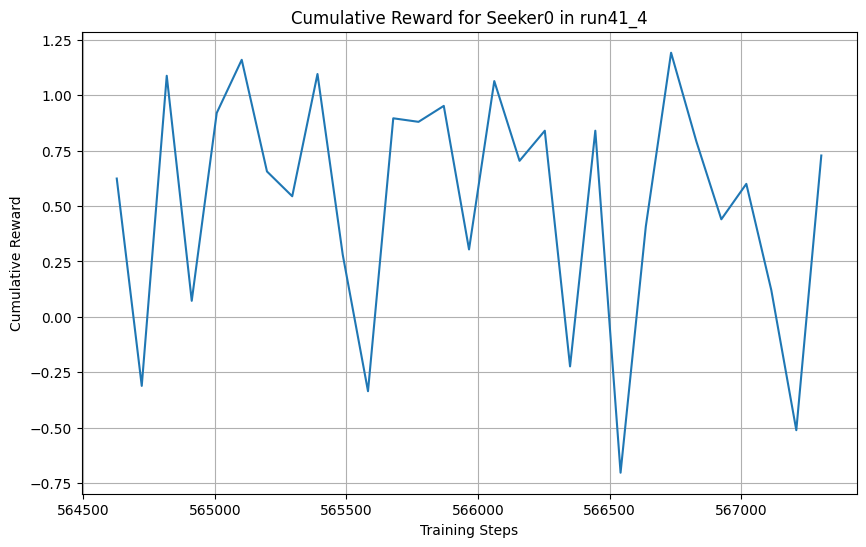

Seeker0 in run41_4: Reward improvement: -0.2224
  -> Rewards not improving


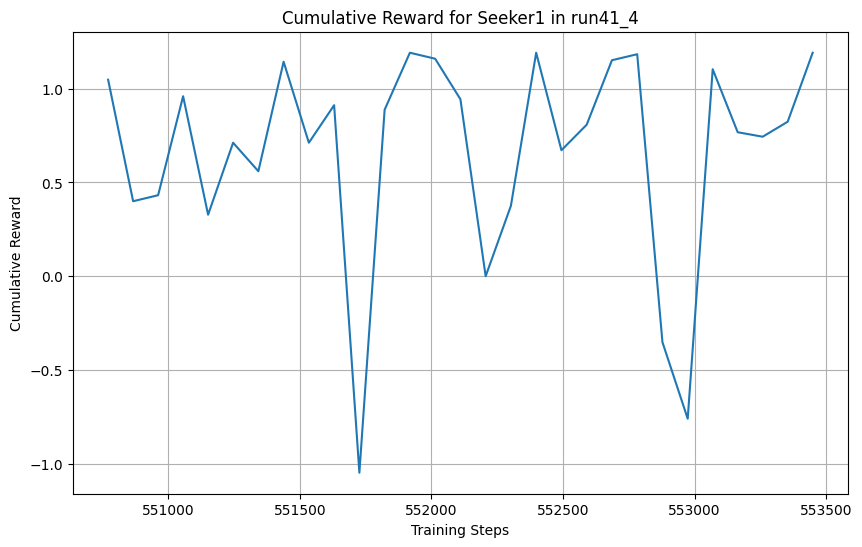

Seeker1 in run41_4: Reward improvement: -0.0544
  -> Rewards not improving


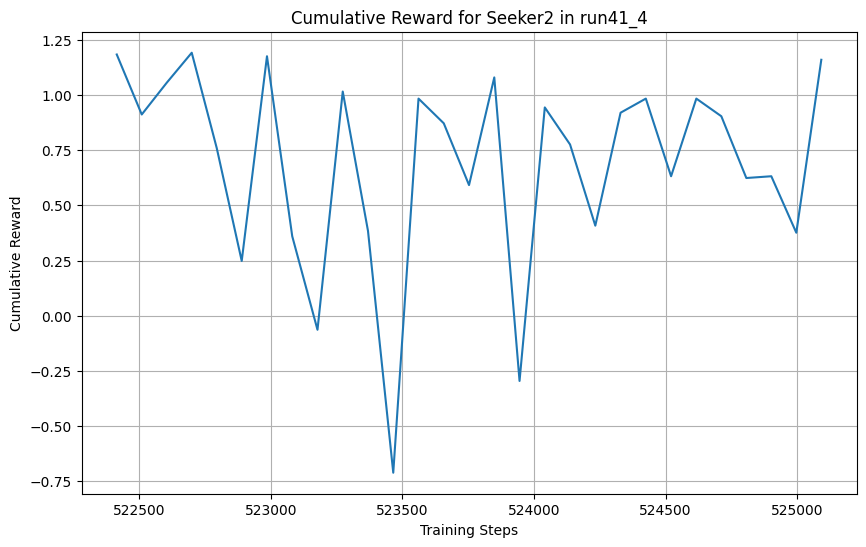

Seeker2 in run41_4: Reward improvement: -0.0216
  -> Rewards not improving


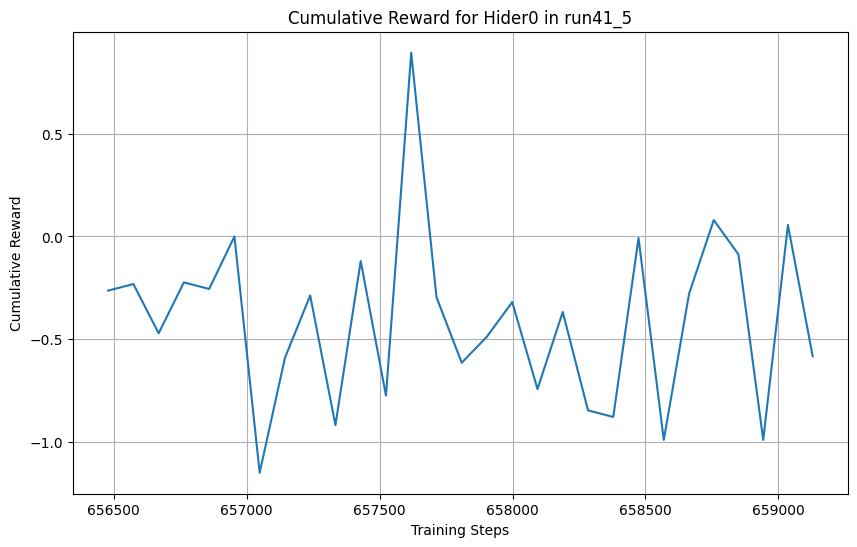

Hider0 in run41_5: Reward improvement: -0.0136
  -> Rewards not improving


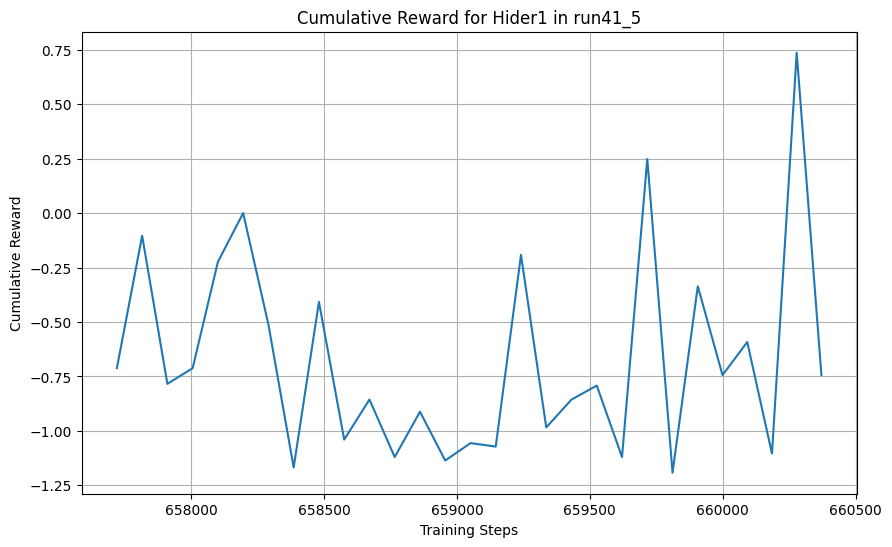

Hider1 in run41_5: Reward improvement: 0.0024
  -> Learning positive rewards


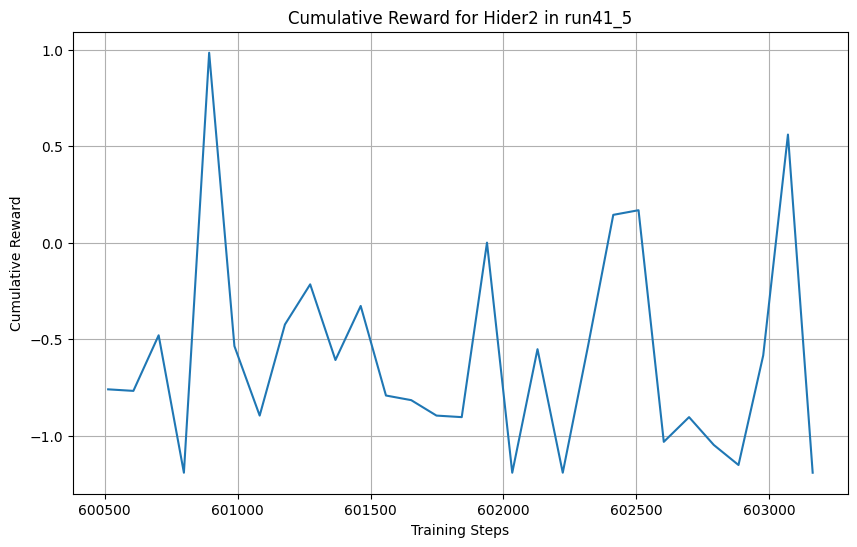

Hider2 in run41_5: Reward improvement: -0.0680
  -> Rewards not improving


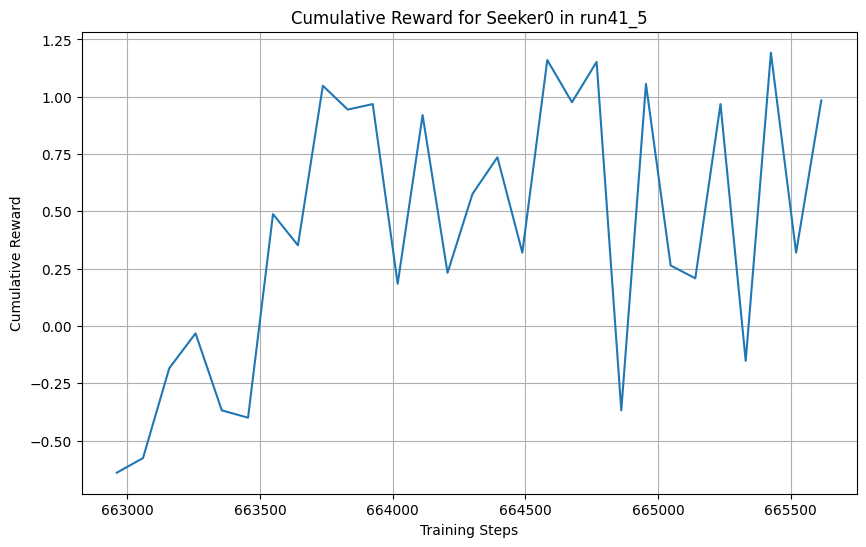

Seeker0 in run41_5: Reward improvement: 0.4992
  -> Learning positive rewards


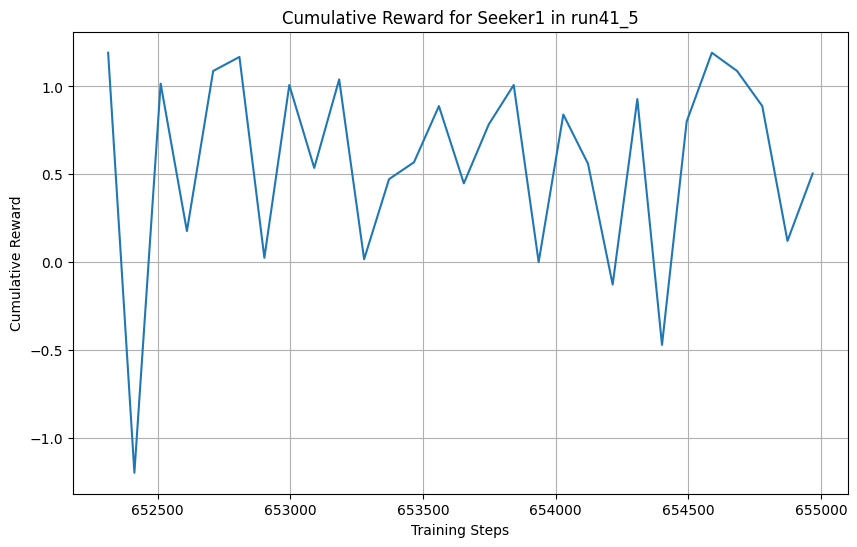

Seeker1 in run41_5: Reward improvement: -0.0568
  -> Rewards not improving


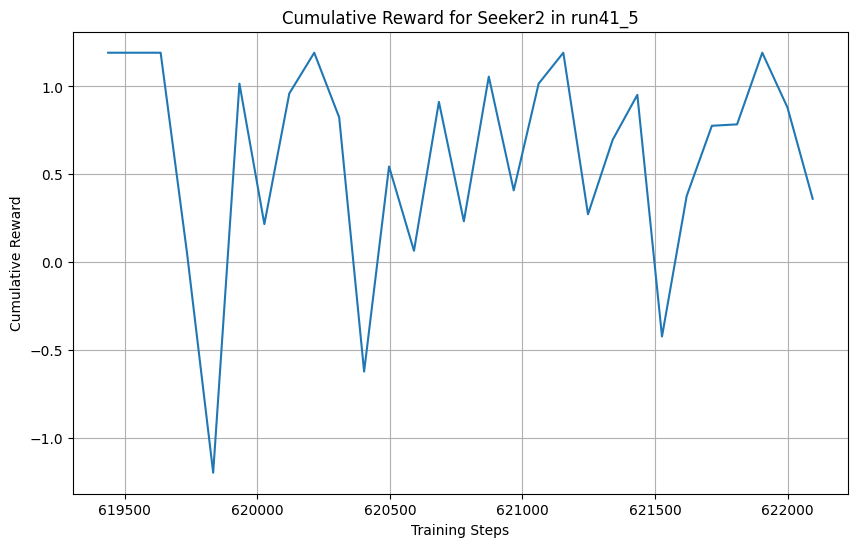

Seeker2 in run41_5: Reward improvement: -0.0776
  -> Rewards not improving


In [7]:
# Plot cumulative rewards
for run_name, agents_data in data.items():
    for agent, metrics in agents_data.items():
        if metrics and metrics['reward']:
            steps, rewards = zip(*metrics['reward'])
            plt.figure(figsize=(10, 6))
            plt.plot(steps, rewards)
            plt.title(f'Cumulative Reward for {agent} in {run_name}')
            plt.xlabel('Training Steps')
            plt.ylabel('Cumulative Reward')
            plt.grid(True)
            plt.show()
            
            # Analyze reward trend
            if len(rewards) > 20:
                early_rewards = rewards[:10]
                late_rewards = rewards[-10:]
                improvement = np.mean(late_rewards) - np.mean(early_rewards)
                print(f'{agent} in {run_name}: Reward improvement: {improvement:.4f}')
                if improvement > 0:
                    print('  -> Learning positive rewards')
                else:
                    print('  -> Rewards not improving')

### 2. Analyze which reward segment contributed most

To do this properly, modify the code to log individual reward components.

In HideAndSeekAgent.cs, add logging for each reward type using StatsRecorder.

In [8]:
# Suggestion for code modification
print("Reward decomposition logging has been added to GameController.cs:")
print("- Reward/VisibilityIndividual_Hider{i}")
print("- Reward/VisibilityIndividual_Seeker{i}")
print("- Reward/VisibilityTeam")
print("- Reward/OobPenalty_Hider{i}")
print("- Reward/OobPenalty_Seeker{i}")
print("- Reward/Capture_Seeker{i}_Hider{j}")
print("Only non-zero rewards are logged to avoid clutter.")
print("Retrain the agents to get decomposed reward logs.")

To decompose rewards, modify HideAndSeekAgent.cs:
Add in the reward addition methods:
statsRecorder.Add('Reward/VisibilityIndividual', visibilityReward);
statsRecorder.Add('Reward/VisibilityTeam', teamVisibilityReward);
statsRecorder.Add('Reward/Capture', captureReward);
statsRecorder.Add('Reward/OobPenalty', oobPenalty);
Then retrain to get decomposed logs.


### 3. Suggestions for next training iteration

Based on the analysis:
- If exploration reduced too early, increase beta (entropy coefficient) in config
- If rewards are not improving, adjust reward weights in GameController
- If certain agents have poor performance, tune their specific hyperparameters
- Add more logging for detailed reward breakdown